# Multivariate Structure and Prediction in the Communities and Crime Dataset

**Course:** Multivariate Data Analysis  

**Author:** Sidharth Saha, Beckham Wee, Beckham Wee, Joe Wang

**Date:** [Date]

## 1. Introduction

### Research Question

What multivariate community-level patterns are associated with above-median violent crime, and how well can those patterns be used to predict `HighViolentCrime`?

### Purpose

This report presents a multivariate analysis of the **Communities and Crime** dataset from the UCI Machine Learning Repository. The goal is to study aggregate community-level associations among socioeconomic, demographic, housing, family-structure, urbanization, and violent-crime variables. The analysis applies multiple multivariate methods covered in the course—including PCA, factor analysis, CCA, clustering, Gaussian mixture models, classification, and regularization—to uncover structure in the data and build predictive models.

### Motivation

Understanding the multivariate structure of community-level characteristics and their statistical association with crime rates is relevant for social science, public policy research, and applied statistics. This dataset offers a rich, high-dimensional setting that motivates the use of dimension-reduction, latent-variable modeling, and supervised classification methods.

### Outcome Variables and Their Role in the Analysis

This project uses two related crime outcome variables:

- **`ViolentCrimesPerPop`**: A normalized continuous measure of per-capita violent crime. This variable is used mainly for exploratory analysis and for comparing average crime levels across PCA scores, factor scores, clusters, and Gaussian mixture components.

- **`HighViolentCrime`**: A derived binary label indicating whether `ViolentCrimesPerPop` is above the sample median. This variable is used as the supervised classification target for logistic regression, LDA, and regularized classification models.

The unsupervised methods in this report—PCA, factor analysis, CCA, clustering, hierarchical clustering, and Gaussian mixture models—are fit using predictor variables rather than the crime outcomes. The outcomes are then used afterward to interpret whether the multivariate structures discovered by these methods are associated with higher or lower violent-crime levels.

### Scope

The project applies the following methods:

- Principal Component Analysis (PCA)
- Factor Analysis
- Canonical Correlation Analysis (CCA)
- K-Means and Hierarchical Clustering
- Gaussian Mixture Models (GMM)
- Logistic Regression, LDA, and Regularized Classification (Ridge, Lasso, Elastic Net)

### Ethical Framing

This dataset is observational and measured at the community level, so the analysis focuses on associations, prediction, and multivariate structure rather than causal claims. Because some variables describe sensitive demographic characteristics, results are interpreted as aggregate community-level patterns and not as claims about individual behavior or group identity.

---
## 2. Data Description and Preprocessing

### Source and Context

The Communities and Crime dataset combines data from three sources:

- **1990 U.S. Census** — socioeconomic, demographic, housing, and family-structure variables.
- **1990 Law Enforcement Management and Administrative Statistics (LEMAS)** — police-force and law-enforcement variables.
- **1995 FBI Uniform Crime Report (UCR)** — violent crime rates.

Each observation represents a U.S. community. The predictor space includes variables measuring income, poverty, education, employment, race/ethnicity composition, housing characteristics, family structure, population density, urbanization, immigration, and law enforcement.

### Preprocessing Already Performed

1. **Identifier columns removed** — non-predictive community identifiers were dropped.
2. **High-missingness variables dropped** — any variable with more than 20% missing values was removed from the dataset.
3. **Median imputation** — remaining numeric missing values were imputed with the column median.
4. **Binary outcome derived** — `HighViolentCrime` was created by thresholding `ViolentCrimesPerPop` at the sample median.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

os.environ["OMP_NUM_THREADS"] = "8"
os.environ["LOKY_MAX_CPU_COUNT"] = "8"
os.environ["MKL_NUM_THREADS"] = "8"

In [2]:
crime = pd.read_csv('datasets/communities_crime.csv')
df = crime.copy()
df.head()

,population,householdsize,racepctblack,racePctWhite,racePctAsian,racePctHisp,agePct12t21,agePct12t29,agePct16t24,agePct65up,...,PctBornSameState,PctSameHouse85,PctSameCity85,PctSameState85,LandArea,PopDens,PctUsePubTrans,LemasPctOfficDrugUn,ViolentCrimesPerPop,HighViolentCrime
0,0.19,0.33,0.02,0.90,0.12,0.17,0.34,0.47,0.29,0.32,...,0.42,0.50,0.51,0.64,0.12,0.26,0.20,0.32,0.20,High
1,0.00,0.16,0.12,0.74,0.45,0.07,0.26,0.59,0.35,0.27,...,0.50,0.34,0.60,0.52,0.02,0.12,0.45,0.00,0.67,High
2,0.00,0.42,0.49,0.56,0.17,0.04,0.39,0.47,0.28,0.32,...,0.49,0.54,0.67,0.56,0.01,0.21,0.02,0.00,0.43,High
3,0.04,0.77,1.00,0.08,0.12,0.10,0.51,0.50,0.34,0.21,...,0.30,0.73,0.64,0.65,0.02,0.39,0.28,0.00,0.12,Low
4,0.01,0.55,0.02,0.95,0.09,0.05,0.38,0.38,0.23,0.36,...,0.72,0.64,0.61,0.53,0.04,0.09,0.02,0.00,0.03,Low


### Why Standardization Matters

The predictor variables are measured on different scales (e.g., percentages, counts, per-capita rates). Many multivariate methods—PCA, factor analysis, CCA, clustering, regularized regression—depend on covariance, correlation, or distance calculations. Without standardization, variables with larger numeric ranges would dominate. **All predictor variables should be standardized (zero mean, unit variance) before analysis.**

Table 2.1 summarizes the retained variables by thematic group. The “Representative Variables” column lists selected examples from each group rather than the full set of variables. Most predictors describe community-level socioeconomic status, education and employment, family structure, immigration and language, housing and residential stability, and urbanization. The dataset contains only one retained law-enforcement variable, `LemasPctOfficDrugUn`, likely because many original law-enforcement variables were removed during preprocessing due to missingness. `ViolentCrimesPerPop` is treated as the continuous outcome, while `HighViolentCrime` is the derived binary classification label.

In [3]:
df.columns.tolist()

['population',
 'householdsize',
 'racepctblack',
 'racePctWhite',
 'racePctAsian',
 'racePctHisp',
 'agePct12t21',
 'agePct12t29',
 'agePct16t24',
 'agePct65up',
 'numbUrban',
 'pctUrban',
 'medIncome',
 'pctWWage',
 'pctWFarmSelf',
 'pctWInvInc',
 'pctWSocSec',
 'pctWPubAsst',
 'pctWRetire',
 'medFamInc',
 'perCapInc',
 'whitePerCap',
 'blackPerCap',
 'indianPerCap',
 'AsianPerCap',
 'OtherPerCap',
 'HispPerCap',
 'NumUnderPov',
 'PctPopUnderPov',
 'PctLess9thGrade',
 'PctNotHSGrad',
 'PctBSorMore',
 'PctUnemployed',
 'PctEmploy',
 'PctEmplManu',
 'PctEmplProfServ',
 'PctOccupManu',
 'PctOccupMgmtProf',
 'MalePctDivorce',
 'MalePctNevMarr',
 'FemalePctDiv',
 'TotalPctDiv',
 'PersPerFam',
 'PctFam2Par',
 'PctKids2Par',
 'PctYoungKids2Par',
 'PctTeen2Par',
 'PctWorkMomYoungKids',
 'PctWorkMom',
 'NumIlleg',
 'PctIlleg',
 'NumImmig',
 'PctImmigRecent',
 'PctImmigRec5',
 'PctImmigRec8',
 'PctImmigRec10',
 'PctRecentImmig',
 'PctRecImmig5',
 'PctRecImmig8',
 'PctRecImmig10',
 'PctSpeakEng

In [4]:
variable_groups = {
    "Population / Urbanization": [
        "population", "householdsize", "numbUrban", "pctUrban",
        "LandArea", "PopDens", "PctUsePubTrans"
    ],

    "Demographic Composition": [
        "racepctblack", "racePctWhite", "racePctAsian", "racePctHisp",
        "agePct12t21", "agePct12t29", "agePct16t24", "agePct65up"
    ],

    "Income / Poverty / Public Assistance": [
        "medIncome", "medFamInc", "perCapInc",
        "whitePerCap", "blackPerCap", "indianPerCap", "AsianPerCap",
        "OtherPerCap", "HispPerCap",
        "NumUnderPov", "PctPopUnderPov",
        "pctWWage", "pctWFarmSelf", "pctWInvInc",
        "pctWSocSec", "pctWPubAsst", "pctWRetire"
    ],

    "Education / Employment / Occupation": [
        "PctLess9thGrade", "PctNotHSGrad", "PctBSorMore",
        "PctUnemployed", "PctEmploy",
        "PctEmplManu", "PctEmplProfServ",
        "PctOccupManu", "PctOccupMgmtProf"
    ],

    "Family Structure": [
        "MalePctDivorce", "MalePctNevMarr", "FemalePctDiv", "TotalPctDiv",
        "PersPerFam", "PctFam2Par", "PctKids2Par",
        "PctYoungKids2Par", "PctTeen2Par",
        "PctWorkMomYoungKids", "PctWorkMom",
        "NumIlleg", "PctIlleg"
    ],

    "Immigration / Language": [
        "NumImmig", "PctImmigRecent", "PctImmigRec5",
        "PctImmigRec8", "PctImmigRec10",
        "PctRecentImmig", "PctRecImmig5",
        "PctRecImmig8", "PctRecImmig10",
        "PctSpeakEnglOnly", "PctNotSpeakEnglWell",
        "PctForeignBorn"
    ],

    "Housing / Residential Stability": [
        "PctLargHouseFam", "PctLargHouseOccup",
        "PersPerOccupHous", "PersPerOwnOccHous", "PersPerRentOccHous",
        "PctPersOwnOccup", "PctPersDenseHous",
        "PctHousLess3BR", "MedNumBR",
        "HousVacant", "PctHousOccup", "PctHousOwnOcc",
        "PctVacantBoarded", "PctVacMore6Mos",
        "MedYrHousBuilt", "PctHousNoPhone", "PctWOFullPlumb",
        "OwnOccLowQuart", "OwnOccMedVal", "OwnOccHiQuart",
        "RentLowQ", "RentMedian", "RentHighQ",
        "MedRent", "MedRentPctHousInc",
        "MedOwnCostPctInc", "MedOwnCostPctIncNoMtg",
        "PctBornSameState", "PctSameHouse85",
        "PctSameCity85", "PctSameState85"
    ],

    "Shelter / Homelessness": [
        "NumInShelters", "NumStreet"
    ],

    "Law Enforcement": [
        "LemasPctOfficDrugUn"
    ],

    "Outcomes": [
        "ViolentCrimesPerPop", "HighViolentCrime"
    ]
}

variable_group_summary = pd.DataFrame([
    {
        "Variable Group": group,
        "Number of Variables": len(cols),
        "Representative Variables": ", ".join(cols[:5]) + ("..." if len(cols) > 5 else "")
    }
    for group, cols in variable_groups.items()
])

pd.set_option("display.max_colwidth", None)
variable_group_summary



,Variable Group,Number of Variables,Representative Variables
0,Population / Urbanization,7,"population, householdsize, numbUrban, pctUrban, LandArea..."
1,Demographic Composition,8,"racepctblack, racePctWhite, racePctAsian, racePctHisp, agePct12t21..."
2,Income / Poverty / Public Assistance,17,"medIncome, medFamInc, perCapInc, whitePerCap, blackPerCap..."
3,Education / Employment / Occupation,9,"PctLess9thGrade, PctNotHSGrad, PctBSorMore, PctUnemployed, PctEmploy..."
4,Family Structure,13,"MalePctDivorce, MalePctNevMarr, FemalePctDiv, TotalPctDiv, PersPerFam..."
5,Immigration / Language,12,"NumImmig, PctImmigRecent, PctImmigRec5, PctImmigRec8, PctImmigRec10..."
6,Housing / Residential Stability,31,"PctLargHouseFam, PctLargHouseOccup, PersPerOccupHous, PersPerOwnOccHous, PersPerRentOccHous..."
7,Shelter / Homelessness,2,"NumInShelters, NumStreet"
8,Law Enforcement,1,LemasPctOfficDrugUn
9,Outcomes,2,"ViolentCrimesPerPop, HighViolentCrime"


Table 2.2 confirms that the retained analysis dataset contains no remaining missing values after preprocessing. Variables with more than 20% missingness were removed before this stage, and remaining numeric missing values were median-imputed. As a result, all retained variables have a missing count of zero in the final modeling dataset.

In [5]:
missingness_report_table = pd.DataFrame({
    "Missingness Category": [
        "Variables with no missing values",
        "Variables with some missing values",
        "Variables with >20% missingness in retained dataset"
    ],
    "Number of Variables": [
        (df.isna().sum() == 0).sum(),
        (df.isna().sum() > 0).sum(),
        ((df.isna().mean() * 100) > 20).sum()
    ]
})

missingness_report_table

,Missingness Category,Number of Variables
0,Variables with no missing values,102
1,Variables with some missing values,0
2,Variables with >20% missingness in retained dataset,0


Table 2.3 reports the class balance for `HighViolentCrime`. Because the binary label was created using the sample median of `ViolentCrimesPerPop`, the two classes are approximately balanced: 993 communities are classified as high violent-crime communities and 1001 are classified as low violent-crime communities. This balanced split means that accuracy is more interpretable than it would be in a highly imbalanced setting, although later classification results should still report sensitivity, specificity, and ROC-AUC.

In [6]:
class_balance = (
    df["HighViolentCrime"]
    .value_counts()
    .rename_axis("Class")
    .reset_index(name="Count")
)

class_balance["Proportion"] = (
    class_balance["Count"] / class_balance["Count"].sum()
).round(3)

class_balance

,Class,Count,Proportion
0,Low,1001,0.502
1,High,993,0.498


Figure 2.1 shows the distribution of `ViolentCrimesPerPop`, the continuous violent-crime outcome. The distribution is right-skewed, with many communities having relatively low values and a smaller number of communities having much higher values near the upper end of the normalized scale. The sample skewness is approximately 1.52, confirming a positive right tail. The dashed vertical line marks the sample median, approximately 0.150, which is used to define the binary outcome `HighViolentCrime`.

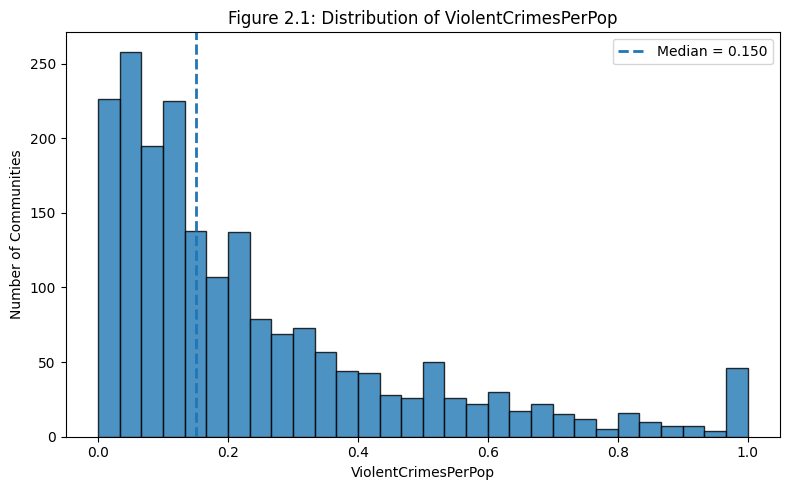

In [7]:
violent_crime = df["ViolentCrimesPerPop"]

median_crime = violent_crime.median()

plt.figure(figsize=(8, 5))
plt.hist(violent_crime, bins=30, edgecolor="black", alpha=0.8)
plt.axvline(median_crime, linestyle="--", linewidth=2, label=f"Median = {median_crime:.3f}")

plt.title("Figure 2.1: Distribution of ViolentCrimesPerPop")
plt.xlabel("ViolentCrimesPerPop")
plt.ylabel("Number of Communities")
plt.legend()
plt.tight_layout()
plt.show()

In [8]:
violent_crime_skewness = violent_crime.skew()
violent_crime_skewness

np.float64(1.522598485536617)

---
## 3. Exploratory Data Analysis

### Purpose

Understand the distributions, correlations, and broad associations among the variables before applying multivariate methods. EDA provides context for later analyses and helps identify potential issues (outliers, non-linearity, strong collinearity).

### Analyses

#### 3.1 Group-Level Summary Statistics

Table 3.1 computes group-level averages of the means, standard deviations, medians, and ranges for the normalized predictor variables within each thematic group. This provides a broad baseline summary of variable magnitude and spread across the retained predictor groups.

In [9]:
group_level_summary = []

for group, cols in variable_groups.items():
    group_data = df[cols]

    group_level_summary.append({
        "Variable Group": group,
        "Number of Variables": len(cols),
        "Average Mean": group_data.mean(numeric_only=True).mean(),
        "Average Std. Dev.": group_data.std(numeric_only=True).mean(),
        "Average Median": group_data.median(numeric_only=True).mean(),
        "Overall Min": group_data.min(numeric_only=True).min(),
        "Overall Max": group_data.max(numeric_only=True).max()
    })

group_level_summary = pd.DataFrame(group_level_summary)

group_level_summary.round(3)

,Variable Group,Number of Variables,Average Mean,Average Std. Dev.,Average Median,Overall Min,Overall Max
0,Population / Urbanization,7,0.249,0.201,0.253,0.0,1.0
1,Demographic Composition,8,0.364,0.198,0.326,0.0,1.0
2,Income / Poverty / Public Assistance,17,0.348,0.187,0.312,0.0,1.0
3,Education / Employment / Occupation,9,0.399,0.196,0.369,0.0,1.0
4,Family Structure,13,0.474,0.182,0.473,0.0,1.0
5,Immigration / Language,12,0.285,0.211,0.239,0.0,1.0
6,Housing / Residential Stability,31,0.404,0.202,0.382,0.0,1.0
7,Shelter / Homelessness,2,0.026,0.102,0.000,0.0,1.0
8,Law Enforcement,1,0.094,0.240,0.000,0.0,1.0
9,Outcomes,2,0.238,0.233,0.150,0.0,1.0


#### 3.2 Distribution of the Violent Crime Outcome

Table 3.2 summarizes the continuous outcome `ViolentCrimesPerPop`. The mean value is 0.238, while the median is lower at 0.150, indicating that the distribution is right-skewed. This is also confirmed by the skewness value of 1.523 and by the boxplot, which shows several communities with unusually high violent-crime values relative to the rest of the sample.

The log-transformed histogram was used as a diagnostic check for skewness. Although the transformation compresses the upper tail, the main supervised analysis uses the binary outcome `HighViolentCrime`, so the continuous outcome is not transformed for the main classification models.

In [10]:
violent_crime = df["ViolentCrimesPerPop"]

crime_summary = pd.DataFrame({
    "Mean": [violent_crime.mean()],
    "Std. Dev.": [violent_crime.std()],
    "Median": [violent_crime.median()],
    "Min": [violent_crime.min()],
    "Max": [violent_crime.max()],
    "Skewness": [violent_crime.skew()]
})

crime_summary.round(3)

,Mean,Std. Dev.,Median,Min,Max,Skewness
0,0.238,0.233,0.15,0.0,1.0,1.523


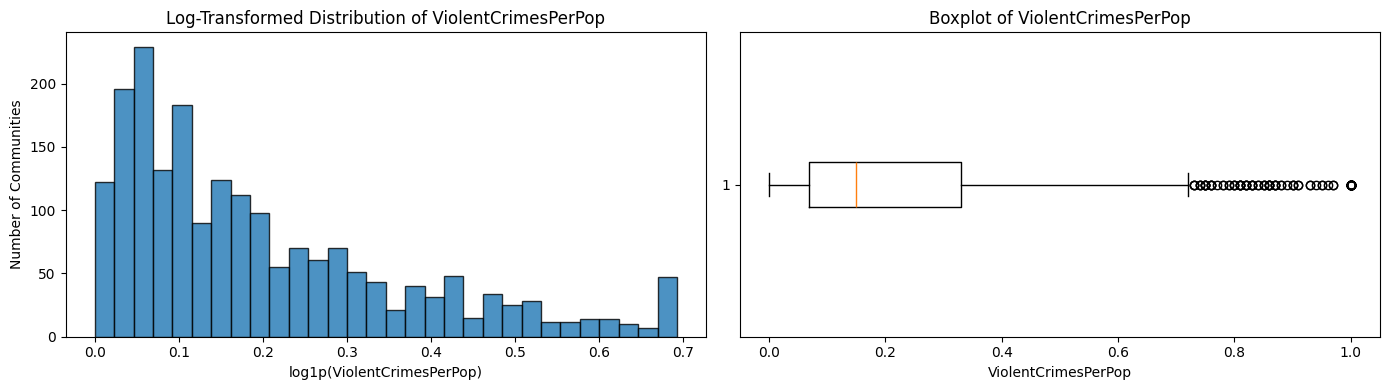

In [11]:
violent_crime = df["ViolentCrimesPerPop"]
violent_crime_log = np.log1p(violent_crime)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Log-transformed histogram
axes[0].hist(violent_crime_log, bins=30, edgecolor="black", alpha=0.8)
axes[0].set_title("Log-Transformed Distribution of ViolentCrimesPerPop")
axes[0].set_xlabel("log1p(ViolentCrimesPerPop)")
axes[0].set_ylabel("Number of Communities")

# Boxplot of original outcome
axes[1].boxplot(violent_crime, vert=False)
axes[1].set_title("Boxplot of ViolentCrimesPerPop")
axes[1].set_xlabel("ViolentCrimesPerPop")

plt.tight_layout()
plt.show()

#### 3.3 Correlation Heatmap

Figure 3.3 shows the correlation structure for a representative subset of variables from the major thematic groups. The full predictor set is too large for a readable heatmap, so selected variables were chosen to cover the main categories in Table 2.1, including population, demographic composition, income, education, family structure, immigration/language, housing, and law enforcement.

The heatmap reveals clear blocks of correlated predictors, especially among income, poverty, education, family-structure, and housing variables. This multicollinearity motivates the use of PCA and factor analysis for dimension reduction, CCA for relationships between variable blocks, and regularized models for more stable prediction. `ViolentCrimesPerPop` is included only as a reference outcome.

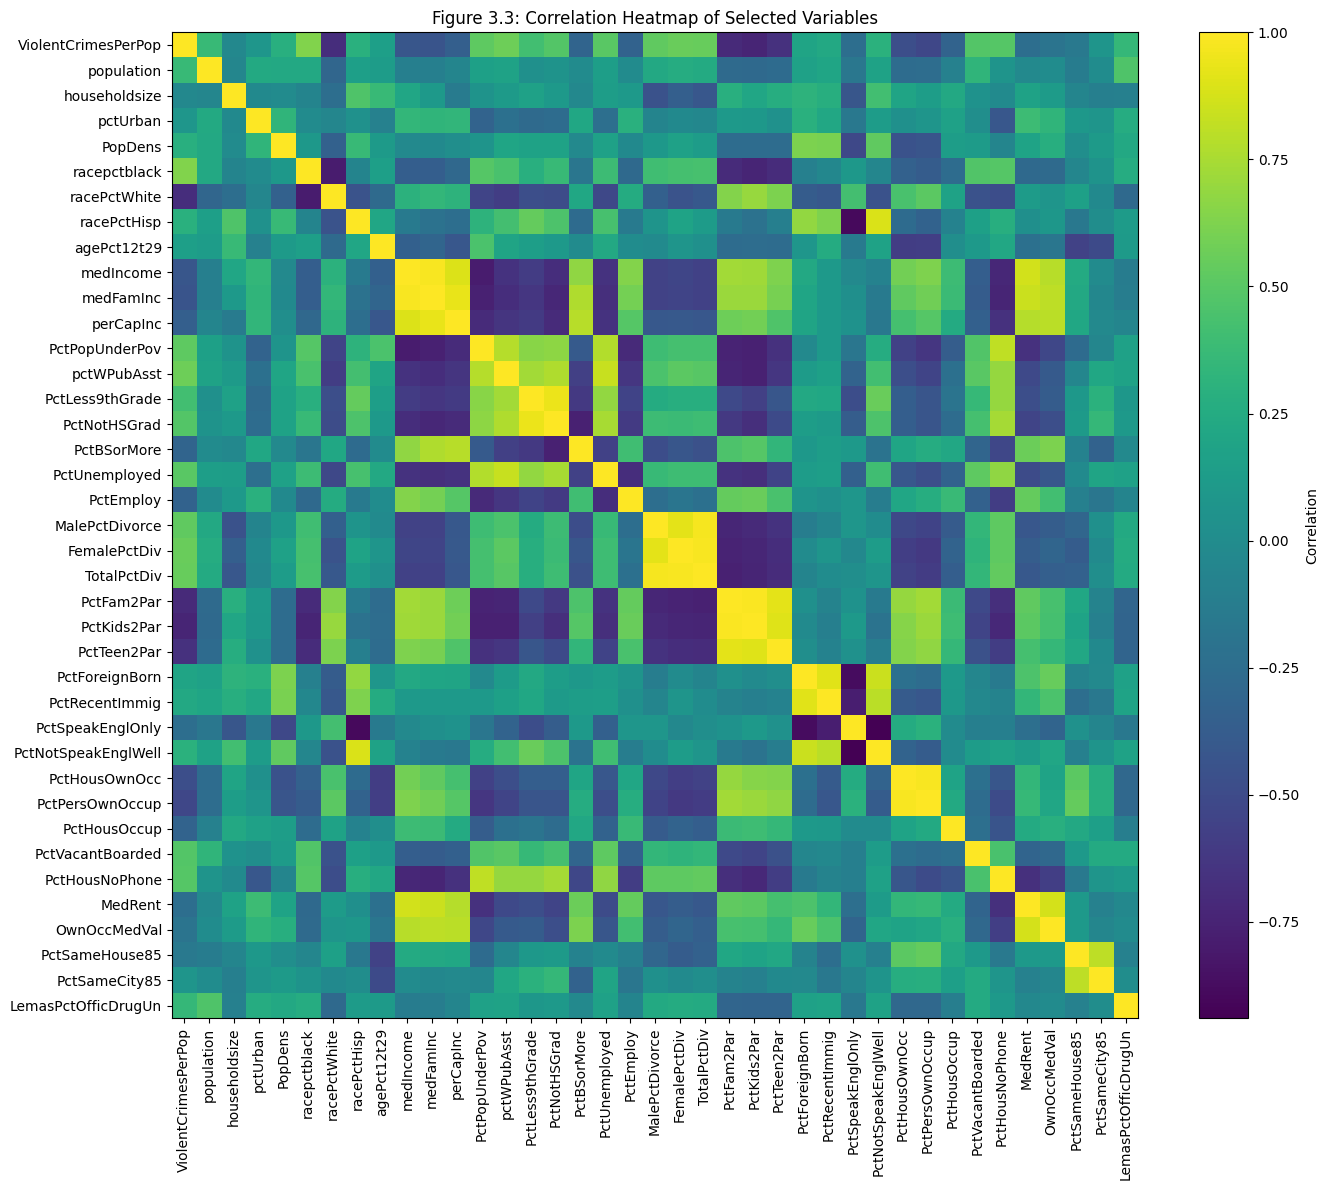

In [12]:
# Representative variables for readable correlation heatmap
heatmap_vars = [
    # Outcome
    "ViolentCrimesPerPop",

    # Population / urbanization
    "population", "householdsize", "pctUrban", "PopDens",

    # Demographic composition
    "racepctblack", "racePctWhite", "racePctHisp", "agePct12t29",

    # Income / poverty
    "medIncome", "medFamInc", "perCapInc", "PctPopUnderPov", "pctWPubAsst",

    # Education / employment
    "PctLess9thGrade", "PctNotHSGrad", "PctBSorMore",
    "PctUnemployed", "PctEmploy",

    # Family structure
    "MalePctDivorce", "FemalePctDiv", "TotalPctDiv",
    "PctFam2Par", "PctKids2Par", "PctTeen2Par",

    # Immigration / language
    "PctForeignBorn", "PctRecentImmig",
    "PctSpeakEnglOnly", "PctNotSpeakEnglWell",

    # Housing / residential stability
    "PctHousOwnOcc", "PctPersOwnOccup", "PctHousOccup",
    "PctVacantBoarded", "PctHousNoPhone",
    "MedRent", "OwnOccMedVal",
    "PctSameHouse85", "PctSameCity85",

    # Law enforcement
    "LemasPctOfficDrugUn"
]

# Keep only variables that exist in the dataframe
heatmap_vars = [col for col in heatmap_vars if col in df.columns]

corr_matrix = df[heatmap_vars].corr()

plt.figure(figsize=(14, 12))
plt.imshow(corr_matrix, aspect="auto")
plt.colorbar(label="Correlation")

plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=90)
plt.yticks(range(len(corr_matrix.index)), corr_matrix.index)

plt.title("Figure 3.3: Correlation Heatmap of Selected Variables")
plt.tight_layout()
plt.show()

#### 3.4 Boxplots: Low vs. High Violent-Crime Communities

Figure 3.4 compares selected normalized predictor variables between low and high violent-crime communities. High violent-crime communities tend to have lower median household income, lower owner-occupied housing, lower percentages of children in two-parent families, and lower bachelor’s degree attainment. They also tend to have higher poverty rates and somewhat higher population density. 

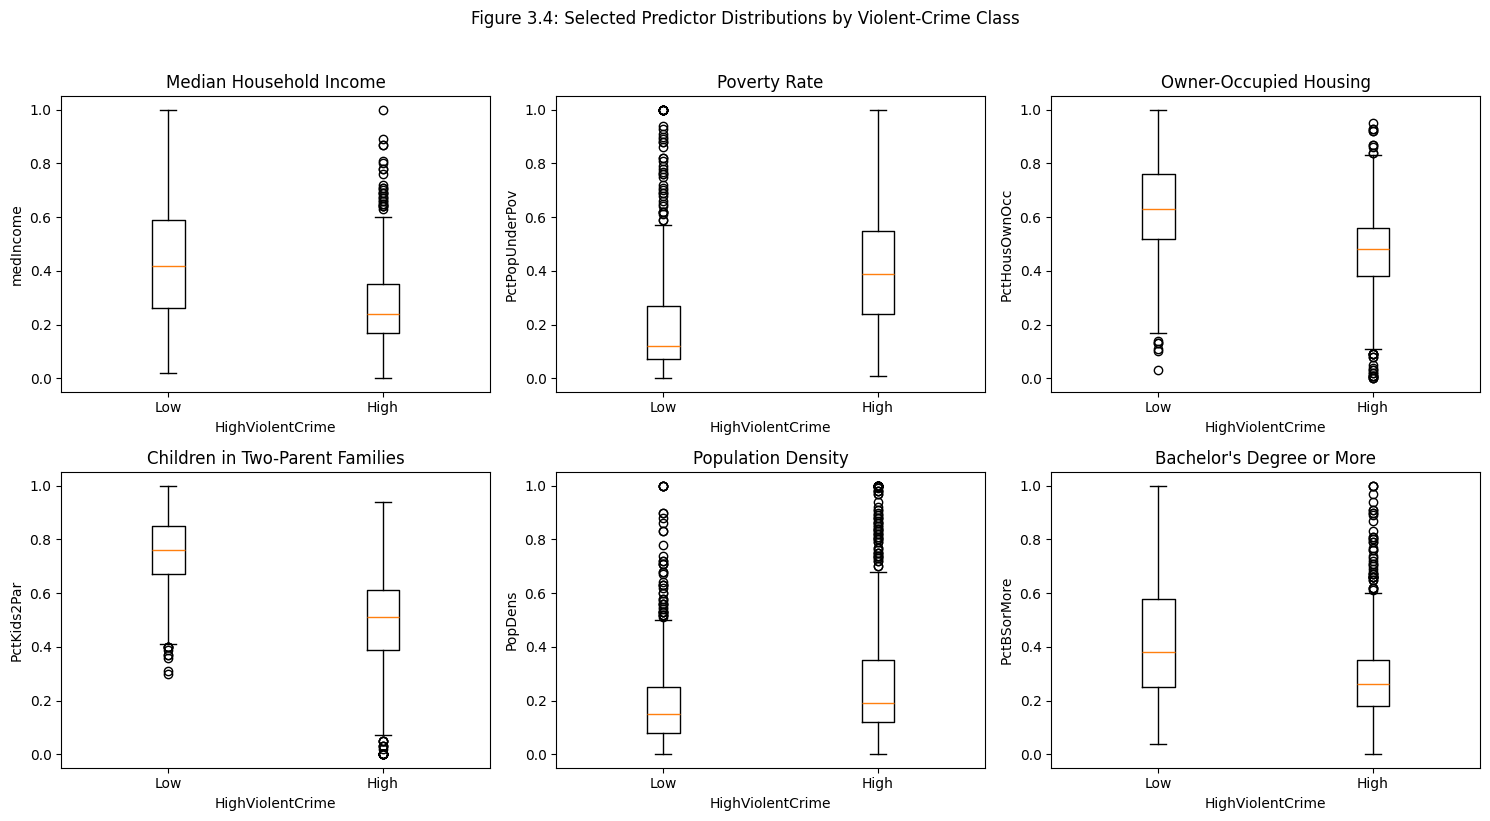

In [13]:
# Representative variables for low vs. high violent-crime comparison
boxplot_vars = {
    "medIncome": "Median Household Income",
    "PctPopUnderPov": "Poverty Rate",
    "PctHousOwnOcc": "Owner-Occupied Housing",
    "PctKids2Par": "Children in Two-Parent Families",
    "PopDens": "Population Density",
    "PctBSorMore": "Bachelor's Degree or More"
}

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for ax, (var, label) in zip(axes, boxplot_vars.items()):
    low_values = df[df["HighViolentCrime"] == "Low"][var]
    high_values = df[df["HighViolentCrime"] == "High"][var]
    
    ax.boxplot([low_values, high_values], tick_labels=["Low", "High"])
    ax.set_title(label)
    ax.set_xlabel("HighViolentCrime")
    ax.set_ylabel(var)

plt.suptitle("Figure 3.4: Selected Predictor Distributions by Violent-Crime Class", y=1.02)
plt.tight_layout()
plt.show()

## 4. PCA: Dimension Reduction of the Full Predictor Space

### 4.1 PCA Workflow and Setup

PCA is used to summarize the high-dimensional predictor space into orthogonal components that capture major directions of variation. Following the course workflow, the PCA analysis proceeds in five steps: data diagnosis, preprocessing choice, PC-count selection, interpretation through loadings and scores, and robustness/limitations.

The PCA is fit only on the predictor variables, excluding `ViolentCrimesPerPop` and `HighViolentCrime`. Although the retained variables are normalized to the 0–1 scale, they do not have equal variance, so correlation PCA is used by standardizing each predictor to mean 0 and standard deviation 1 before fitting PCA.

In [14]:
from sklearn.preprocessing import StandardScaler
import pandas as pd

# Define outcome columns
outcome_cols = ["ViolentCrimesPerPop", "HighViolentCrime"]

# Predictor matrix only
X = df.drop(columns=outcome_cols)

# Standardize predictors for correlation PCA
scaler = StandardScaler()

X_scaled = pd.DataFrame(
    scaler.fit_transform(X),
    columns=X.columns,
    index=X.index
)

# Quick checks
pca_setup_summary = pd.DataFrame({
    "Object": ["Original predictor matrix", "Standardized predictor matrix"],
    "Rows": [X.shape[0], X_scaled.shape[0]],
    "Columns": [X.shape[1], X_scaled.shape[1]],
    "Mean Check": [round(X.mean().mean(), 3), round(X_scaled.mean().mean(), 3)],
    "Std. Dev. Check": [round(X.std().mean(), 3), round(X_scaled.std().mean(), 3)]
})

pca_setup_summary

,Object,Rows,Columns,Mean Check,Std. Dev. Check
0,Original predictor matrix,1994,100,0.364,0.196
1,Standardized predictor matrix,1994,100,-0.000,1.000


The PCA setup table confirms that the analysis uses 100 predictor variables after excluding `ViolentCrimesPerPop` and `HighViolentCrime`. Although the original predictors are normalized, their average standard deviation is only 0.196, meaning they do not have equal variance. After standardization, the predictors have approximately mean 0 and standard deviation 1, so the PCA is fit as correlation PCA.

### 4.2 Step 1: Data Diagnosis

Before fitting PCA, the dataset was checked for missingness, outcome distribution, and correlation structure. Table 2.2 confirms that the retained modeling dataset contains no remaining missing values after preprocessing. Figure 3.3 shows strong blocks of correlated predictors, especially among income, poverty, education, family-structure, and housing variables. This correlation structure supports the use of PCA because the predictors contain shared multivariate variation that can be summarized through lower-dimensional components.

### 4.3 Step 2: Preprocessing Choice — Correlation PCA

PCA can be fit either on the covariance matrix or the correlation matrix. Because the predictors represent different types of community characteristics and still have unequal variances after normalization, this analysis uses correlation PCA. This means each predictor is standardized before PCA so that the components reflect shared correlation structure rather than differences in variable spread.

The standardized predictor matrix from Section 4.1 is used for the PCA fit.

In [15]:
from sklearn.decomposition import PCA

pca = PCA()
pca_scores = pca.fit_transform(X_scaled)

pca_scores_df = pd.DataFrame(
    pca_scores,
    columns=[f"PC{i+1}" for i in range(pca_scores.shape[1])],
    index=df.index
)

explained_variance = pca.explained_variance_
explained_variance_ratio = pca.explained_variance_ratio_
cumulative_variance = explained_variance_ratio.cumsum()

pca_fit_summary = pd.DataFrame({
    "Number of Observations": [X_scaled.shape[0]],
    "Number of Predictors": [X_scaled.shape[1]],
    "Number of PCs Computed": [pca_scores_df.shape[1]],
    "Total Variance Explained": [round(explained_variance_ratio.sum(), 3)]
})

pca_fit_summary

,Number of Observations,Number of Predictors,Number of PCs Computed,Total Variance Explained
0,1994,100,100,1.0


The PCA fit uses 100 standardized predictor variables after excluding `ViolentCrimesPerPop` and `HighViolentCrime`. Because all 100 PCs are computed, the total variance explained across the full set of components is 1.0, as expected. This confirms that the PCA model was fit correctly on the standardized predictor matrix.

### 4.4 Step 3: Choosing the Number of PCs

Figure 4.1 compares several criteria for choosing the number of principal components. The scree plot shows a steep decline in eigenvalues for the first several PCs, followed by a flatter region where additional components contribute less variance. The Kaiser rule retains PCs with eigenvalues greater than 1, while parallel analysis compares the observed eigenvalues to eigenvalues generated from random noise data of the same size.

These criteria do not need to give the same answer. The first few PCs are emphasized for interpretation because they explain the largest shares of variance and are most interpretable. A larger set of PCs may be retained for downstream clustering, GMM, and classification depending on the cumulative-variance and parallel-analysis results.

Figure 4.1 compares several criteria for choosing the number of PCs. The scree plot shows a steep decline in eigenvalues for the first several components, followed by a flatter region. The Kaiser rule retains 14 PCs, while parallel analysis suggests retaining 13 PCs because those observed eigenvalues exceed the random-data benchmark. The 80% cumulative-variance criterion requires 11 PCs. Taken together, these criteria suggest that roughly 11–14 PCs capture meaningful structure for downstream analysis, while the first four PCs are emphasized for interpretation because they explain the largest individual shares of variance.

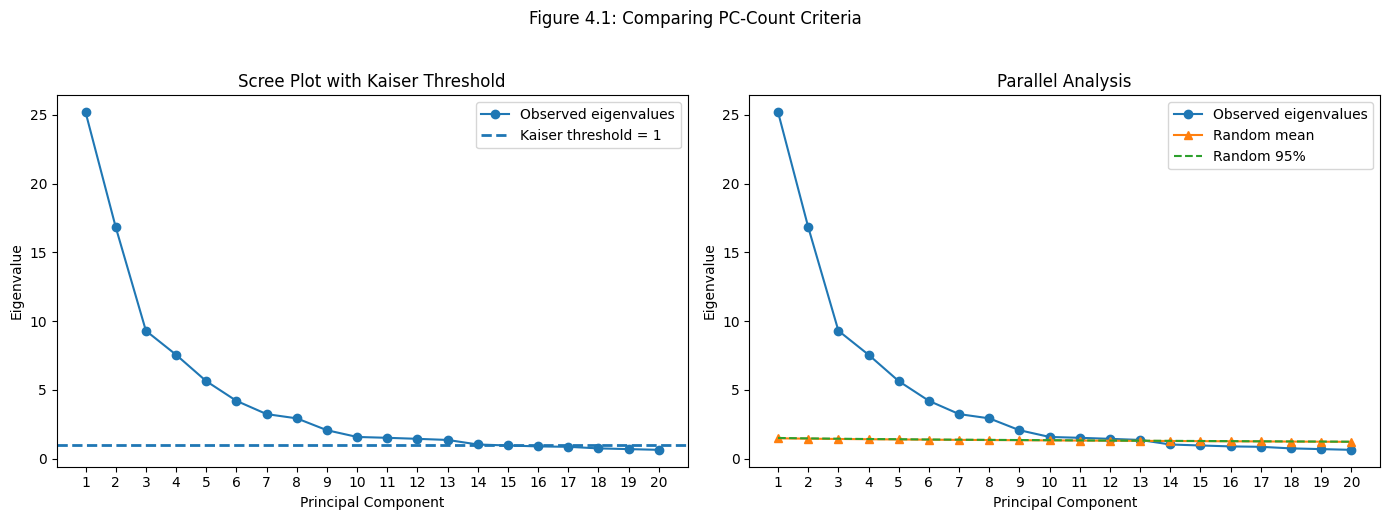

,Criterion,Number of PCs Suggested
0,80% cumulative variance,11
1,Kaiser rule: eigenvalue > 1,14
2,Parallel analysis: observed > random mean,13
3,Parallel analysis: observed > random 95%,13


In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# Observed PCA eigenvalues
observed_eigenvalues = explained_variance

# Kaiser rule
kaiser_pcs = (observed_eigenvalues > 1).sum()

# 80% cumulative variance rule
pcs_for_80 = (cumulative_variance < 0.80).sum() + 1

# Parallel analysis setup
n_simulations = 100
n_obs, n_vars = X_scaled.shape

random_eigenvalues = np.zeros((n_simulations, n_vars))

for i in range(n_simulations):
    random_data = np.random.normal(size=(n_obs, n_vars))
    random_pca = PCA().fit(random_data)
    random_eigenvalues[i, :] = random_pca.explained_variance_

random_mean = random_eigenvalues.mean(axis=0)
random_95 = np.percentile(random_eigenvalues, 95, axis=0)

# Parallel analysis rule
parallel_mean_pcs = (observed_eigenvalues > random_mean).sum()
parallel_95_pcs = (observed_eigenvalues > random_95).sum()

# Display first 20 PCs in plots
max_pc_plot = 20
pc_numbers = np.arange(1, max_pc_plot + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scree plot with Kaiser threshold
axes[0].plot(
    pc_numbers,
    observed_eigenvalues[:max_pc_plot],
    marker="o",
    label="Observed eigenvalues"
)

axes[0].axhline(
    y=1,
    linestyle="--",
    linewidth=2,
    label="Kaiser threshold = 1"
)

axes[0].set_title("Scree Plot with Kaiser Threshold")
axes[0].set_xlabel("Principal Component")
axes[0].set_ylabel("Eigenvalue")
axes[0].set_xticks(pc_numbers)
axes[0].legend()

# Parallel analysis plot
axes[1].plot(
    pc_numbers,
    observed_eigenvalues[:max_pc_plot],
    marker="o",
    label="Observed eigenvalues"
)

axes[1].plot(
    pc_numbers,
    random_mean[:max_pc_plot],
    marker="^",
    label="Random mean"
)

axes[1].plot(
    pc_numbers,
    random_95[:max_pc_plot],
    linestyle="--",
    label="Random 95%"
)

axes[1].set_title("Parallel Analysis")
axes[1].set_xlabel("Principal Component")
axes[1].set_ylabel("Eigenvalue")
axes[1].set_xticks(pc_numbers)
axes[1].legend()

plt.suptitle("Figure 4.1: Comparing PC-Count Criteria", y=1.03)
plt.tight_layout()
plt.show()

pc_count_summary = pd.DataFrame({
    "Criterion": [
        "80% cumulative variance",
        "Kaiser rule: eigenvalue > 1",
        "Parallel analysis: observed > random mean",
        "Parallel analysis: observed > random 95%"
    ],
    "Number of PCs Suggested": [
        pcs_for_80,
        kaiser_pcs,
        parallel_mean_pcs,
        parallel_95_pcs
    ]
})

pc_count_summary

### 4.5 Step 4: Interpreting PC Loadings

PC loadings show which original variables contribute most strongly to each principal component. Table 4.2 reports the ten highest-magnitude loadings for the first four PCs. Although the PC-count criteria suggest retaining roughly 11–14 PCs for downstream analysis, the loading interpretation focuses on the first four PCs because they explain the largest individual shares of variance and have the clearest loading patterns.

The signs of the loadings are interpreted relatively. Flipping the sign of a PC would not change the underlying component, so the interpretation focuses on which variables move together or in opposite directions.

**PC1: Economic advantage / family stability.**  
PC1 has positive loadings on `medFamInc`, `medIncome`, `perCapInc`, `PctKids2Par`, `PctFam2Par`, and `PctYoungKids2Par`, and negative loadings on `PctPopUnderPov`, `pctWPubAsst`, and `PctHousNoPhone`. This component contrasts communities with higher income and stronger two-parent family structure against communities with higher poverty, public assistance, and housing disadvantage.

**PC2: Immigration / language composition.**  
PC2 has high positive loadings on recent immigration variables such as `PctRecImmig10`, `PctRecImmig8`, `PctRecImmig5`, `PctRecentImmig`, and `PctForeignBorn`, along with a negative loading on `PctSpeakEnglOnly`. This component mainly captures variation related to immigration recency, foreign-born population share, and language patterns.

**PC3: Household size / occupancy structure.**  
PC3 loads strongly on `PersPerOccupHous`, `PersPerFam`, `PersPerOwnOccHous`, `householdsize`, `PersPerRentOccHous`, and large-household variables. This component describes household size and occupancy intensity, with larger household and family structures on the positive side.

**PC4: Residential stability and age composition.**  
PC4 has positive loadings on `PctSameCity85`, `PctSameHouse85`, `agePct65up`, and `pctWSocSec`, and negative loadings on younger age-share variables such as `agePct12t29`, `agePct16t24`, and `agePct12t21`. This component contrasts older, more residentially stable communities with younger, more mobile communities.

In [17]:
# PCA loadings for all components
loadings = pd.DataFrame(
    pca.components_.T,
    index=X_scaled.columns,
    columns=[f"PC{i+1}" for i in range(pca.components_.shape[0])]
)

# Side-by-side top loading table for first 4 PCs
top_n = 10
pcs_to_interpret = ["PC1", "PC2", "PC3", "PC4"]

side_by_side_loadings = pd.DataFrame()

for pc in pcs_to_interpret:
    pc_loadings = loadings[[pc]].copy()
    pc_loadings["Abs Loading"] = pc_loadings[pc].abs()
    pc_loadings = pc_loadings.sort_values("Abs Loading", ascending=False).head(top_n)
    
    pc_table = pd.DataFrame({
        f"{pc} Variable": pc_loadings.index,
        f"{pc} Loading": pc_loadings[pc].round(3).values
    })
    
    side_by_side_loadings = pd.concat(
        [side_by_side_loadings, pc_table.reset_index(drop=True)],
        axis=1
    )

side_by_side_loadings

,PC1 Variable,PC1 Loading,PC2 Variable,PC2 Loading,PC3 Variable,PC3 Loading,PC4 Variable,PC4 Loading
0,medFamInc,0.183,PctRecImmig10,0.219,PersPerOccupHous,0.254,PctSameCity85,0.260
1,medIncome,0.182,PctRecImmig8,0.219,PersPerFam,0.232,agePct12t29,-0.254
2,PctKids2Par,0.175,PctRecImmig5,0.217,PersPerOwnOccHous,0.224,PctSameHouse85,0.246
3,pctWInvInc,0.174,PctRecentImmig,0.214,householdsize,0.223,agePct16t24,-0.243
4,PctPopUnderPov,-0.173,PctForeignBorn,0.213,PersPerRentOccHous,0.203,agePct12t21,-0.240
5,PctFam2Par,0.172,PctSpeakEnglOnly,-0.191,PctLargHouseOccup,0.201,agePct65up,0.200
6,PctYoungKids2Par,0.171,PctNotSpeakEnglWell,0.188,HousVacant,-0.170,pctWSocSec,0.191
7,perCapInc,0.169,PctPersDenseHous,0.175,PctLargHouseFam,0.169,PctImmigRec5,-0.180
8,pctWPubAsst,-0.164,racePctAsian,0.167,numbUrban,-0.151,PctImmigRecent,-0.178
9,PctHousNoPhone,-0.164,racePctHisp,0.162,population,-0.149,PctImmigRec8,-0.176


### 4.6 Step 5: Interpreting PC Scores

PC scores show where each community falls along the principal component directions. Figure 4.2 plots the first two PC scores and colors each community by `HighViolentCrime` to assess whether the unsupervised PCA structure aligns with the binary outcome.

The clearest separation appears along PC1. Low violent-crime communities are more concentrated on the positive side of PC1, while high violent-crime communities are more concentrated on the negative side. Based on the PC1 loadings, this suggests that the economic advantage / family stability dimension is strongly associated with the violent-crime label.

PC2 shows greater overlap between the two classes, suggesting that the immigration/language composition dimension does not separate high and low violent-crime communities as clearly in this two-dimensional view. Because PCA was fit without using `HighViolentCrime`, this pattern reflects an association between the predictor structure and the outcome, not a supervised classification result.

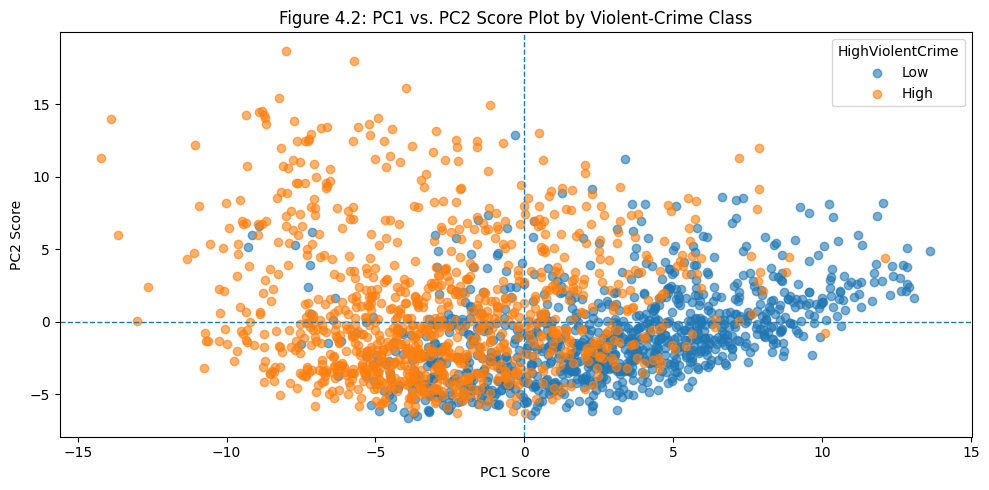

In [18]:
import matplotlib.pyplot as plt

# Combine PCA scores with violent-crime class label
pca_plot_df = pca_scores_df[["PC1", "PC2"]].copy()
pca_plot_df["HighViolentCrime"] = df["HighViolentCrime"]

plt.figure(figsize=(10, 5))

for label in ["Low", "High"]:
    subset = pca_plot_df[pca_plot_df["HighViolentCrime"] == label]
    plt.scatter(
        subset["PC1"],
        subset["PC2"],
        alpha=0.6,
        label=label
    )

plt.axhline(0, linewidth=1, linestyle="--")
plt.axvline(0, linewidth=1, linestyle="--")

plt.title("Figure 4.2: PC1 vs. PC2 Score Plot by Violent-Crime Class")
plt.xlabel("PC1 Score")
plt.ylabel("PC2 Score")
plt.legend(title="HighViolentCrime")
plt.tight_layout()
plt.show()

### 4.7 PCA Summary and Use in Later Sections

PCA reduced the 100 standardized predictors into a smaller set of orthogonal summaries. The first two PCs explain 42.0% of the total variance, the first five explain 64.5%, and the first eleven explain approximately 80.0%. Kaiser and parallel analysis suggest retaining about 13–14 PCs, so the later clustering, GMM, and classification sections will use a retained PC-score matrix rather than all 100 original predictors.

For interpretation, only the first four PCs are labeled: PC1 captures economic advantage/family stability, PC2 captures immigration/language composition, PC3 captures household and occupancy structure, and PC4 captures residential stability/age composition. The PC1 score plot also shows clear alignment with `HighViolentCrime`, with high violent-crime communities concentrated more on the lower-PC1 side.

## 5. Factor Analysis: Latent Community Structure

### 5.1 Why Factor Analysis and How It Complements PCA

Factor analysis (FA) models the observed predictor correlations as products of a small number of **latent factors** plus variable-specific uniqueness terms. While PCA decomposes total variance into orthogonal components, FA explicitly separates **shared variance** (explained by latent factors) from **unique variance** (specific to each variable). This makes FA a natural complement to PCA when the goal is to identify interpretable latent community-level dimensions.

| Aspect | PCA | Factor Analysis |
|--------|-----|-----------------|
| Goal | Maximize total variance explained | Model shared covariance via latent factors |
| Model | Linear combinations of observed variables | Observed variables = factor loadings × latent factors + uniqueness |
| Rotation | Components are orthogonal by construction | Loadings can be rotated (varimax, promax) for interpretability |
| Uniqueness | Not separated | Each variable has an explicit uniqueness term |

**Workflow for this section:**

| Step | Task | Key Output |
|------|------|------------|
| 1 | Setup — same standardized predictor matrix as PCA | Correlation matrix, dimensions confirmed |
| 2 | Factor selection diagnostics — parallel analysis + RMSR | Narrow the candidate range |
| 3 | Compare candidate models — rotated loadings side by side | Choose the final factor count |
| 4 | Final model — rotated loading table and factor interpretation | Named latent dimensions |
| 5 | Factor scores by violent-crime class | Boxplots linking factors to the outcome |

### 5.2 Step 1: Setup

Factor analysis uses the same standardized predictor matrix from the PCA section (`X_scaled`), containing 100 predictor variables across 1,994 communities. The observed predictor correlation matrix is created here because factor selection and residual checks are based on how well the factor model reproduces this correlation structure.

In [19]:
# Factor analysis uses the same standardized predictor matrix from PCA
X_fa = X_scaled.copy()

# Observed predictor correlation matrix (used for diagnostics throughout)
R_observed = X_fa.corr()

# Setup summary
fa_setup_summary = pd.DataFrame({
    "Object": [
        "Standardized predictor matrix",
        "Observed correlation matrix"
    ],
    "Rows": [X_fa.shape[0], R_observed.shape[0]],
    "Columns": [X_fa.shape[1], R_observed.shape[1]]
})

fa_setup_summary

,Object,Rows,Columns
0,Standardized predictor matrix,1994,100
1,Observed correlation matrix,100,100


The factor analysis starts from the same 1,994 × 100 standardized predictor matrix used in PCA. The 100 × 100 observed correlation matrix will serve as the reference for all residual-fit checks below.

### 5.3 Step 2: Factor Selection Diagnostics

Two diagnostics are used to narrow the candidate range for the number of factors:

1. **Parallel analysis** — compares the observed eigenvalues of the correlation matrix against eigenvalues from randomly generated data of the same dimensions. Factors whose observed eigenvalues exceed the random reference contain more structure than noise. This provides an **upper bound** on the number of meaningful factors.

2. **Residual correlation RMSR** — for each candidate factor count, the factor model is fit and the model-implied correlation matrix is compared to the observed one. The root-mean-square of the off-diagonal residual correlations (RMSR) measures how much correlation structure remains unexplained. Lower RMSR indicates better fit.

Together, parallel analysis identifies how many factors are statistically distinguishable from noise, while RMSR shows where adding more factors stops meaningfully improving the fit.

In [20]:
from sklearn.decomposition import FactorAnalysis
import numpy as np
import matplotlib.pyplot as plt

# ── Parallel analysis ──
n_simulations = 100
n_obs, n_vars = X_fa.shape

observed_eigenvalues = np.linalg.eigvalsh(R_observed)[::-1]

random_eigenvalues = np.zeros((n_simulations, n_vars))
for i in range(n_simulations):
    random_data = np.random.normal(size=(n_obs, n_vars))
    random_corr = pd.DataFrame(random_data).corr()
    random_eigenvalues[i, :] = np.linalg.eigvalsh(random_corr)[::-1]

random_mean = random_eigenvalues.mean(axis=0)
random_95 = np.percentile(random_eigenvalues, 95, axis=0)

parallel_mean_factors = int((observed_eigenvalues > random_mean).sum())
parallel_95_factors = int((observed_eigenvalues > random_95).sum())

# ── RMSR across candidate factor counts ──
def compute_fa_rmsr(X_data, n_factors):
    """Fit a varimax-rotated FA model and return off-diagonal residual correlation RMSR."""
    fa = FactorAnalysis(n_components=n_factors, rotation="varimax", random_state=42)
    fa.fit(X_data)
    loadings = fa.components_.T
    R_hat = loadings @ loadings.T + np.diag(fa.noise_variance_)
    d = np.sqrt(np.diag(R_hat))
    R_hat_corr = R_hat / np.outer(d, d)
    residual = R_observed.values - R_hat_corr
    off_diag = residual[np.triu_indices_from(residual, k=1)]
    return np.sqrt(np.mean(off_diag ** 2))

candidate_range = range(2, 16)
rmsr_results = pd.DataFrame({
    "Factors": list(candidate_range),
    "RMSR": [compute_fa_rmsr(X_fa, m) for m in candidate_range]
})
rmsr_results["RMSR Improvement"] = rmsr_results["RMSR"].shift(1) - rmsr_results["RMSR"]

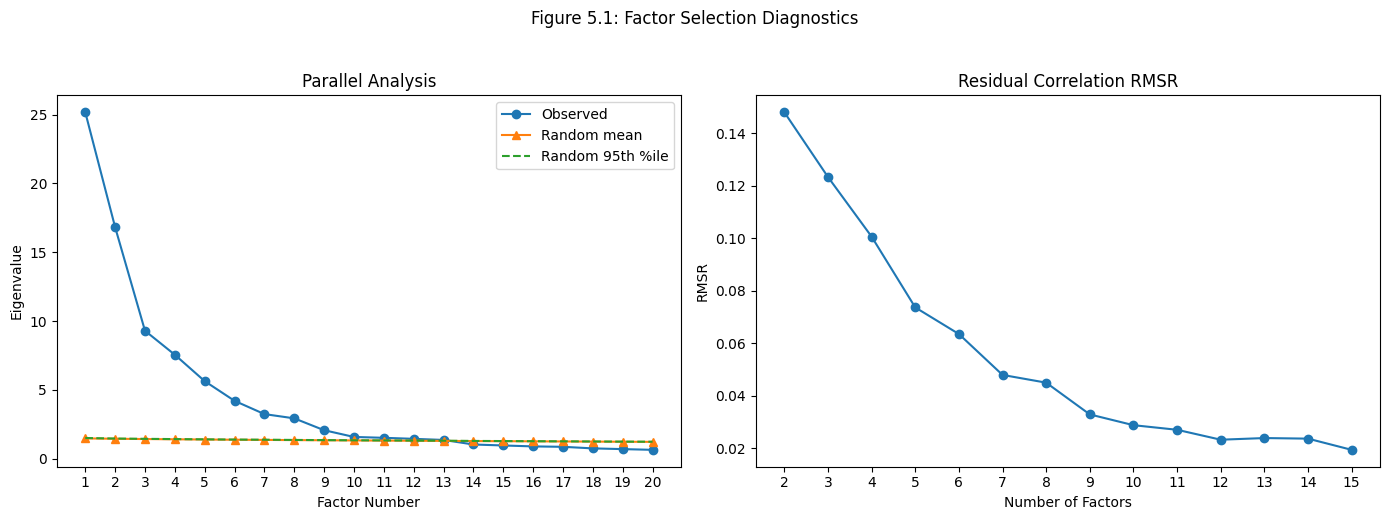

In [21]:
# ── Figure 5.1: Factor selection diagnostics (parallel analysis + RMSR) ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Parallel analysis
max_plot = 20
factor_numbers = np.arange(1, max_plot + 1)
axes[0].plot(factor_numbers, observed_eigenvalues[:max_plot], marker="o", label="Observed")
axes[0].plot(factor_numbers, random_mean[:max_plot], marker="^", label="Random mean")
axes[0].plot(factor_numbers, random_95[:max_plot], linestyle="--", label="Random 95th %ile")
axes[0].set_title("Parallel Analysis")
axes[0].set_xlabel("Factor Number")
axes[0].set_ylabel("Eigenvalue")
axes[0].set_xticks(factor_numbers)
axes[0].legend()

# Right: RMSR curve
axes[1].plot(rmsr_results["Factors"], rmsr_results["RMSR"], marker="o")
axes[1].set_title("Residual Correlation RMSR")
axes[1].set_xlabel("Number of Factors")
axes[1].set_ylabel("RMSR")
axes[1].set_xticks(list(candidate_range))

plt.suptitle("Figure 5.1: Factor Selection Diagnostics", y=1.03)
plt.tight_layout()
plt.show()

In [22]:
# ── Table 5.1: Diagnostic summary ──
diagnostic_summary = pd.DataFrame({
    "Criterion": [
        "Parallel analysis (observed > random mean)",
        "Parallel analysis (observed > random 95th percentile)"
    ],
    "Suggested Factors": [parallel_mean_factors, parallel_95_factors]
})

print("Table 5.1a: Parallel Analysis Summary")
display(diagnostic_summary)

print("\nTable 5.1b: RMSR by Factor Count")
display(rmsr_results.round(4))

Table 5.1a: Parallel Analysis Summary


,Criterion,Suggested Factors
0,Parallel analysis (observed > random mean),13
1,Parallel analysis (observed > random 95th percentile),13



Table 5.1b: RMSR by Factor Count


,Factors,RMSR,RMSR Improvement
0,2,0.1481,NaN
1,3,0.1234,0.0247
2,4,0.1007,0.0227
3,5,0.0737,0.0270
4,6,0.0635,0.0101
5,7,0.0479,0.0156
6,8,0.0450,0.0030
7,9,0.0329,0.0121
8,10,0.0288,0.0041
9,11,0.0270,0.0018


**Reading the diagnostics:**

- Parallel analysis suggests up to roughly 13 factors contain more structure than random noise. However, a 13-factor model would be difficult to interpret and would not provide a concise latent structure.
- The RMSR curve shows the sharpest improvements in the 4–7 factor range, with diminishing returns beyond about 7–8 factors.
- **Decision:** The candidate range for detailed comparison is narrowed to **7–10 factors** — enough to capture the main structure while remaining interpretable. The next step compares their rotated loading patterns side by side.

### 5.4 Step 3: Compare Candidate Models (7, 8, 9, 10 Factors)

To choose the final factor count, all four candidate models are fit with varimax rotation, and their top-loading variables are displayed side by side. The comparison asks:

- Do the factors correspond to **clear, distinct themes** (economic disadvantage, housing, family, urbanization, etc.)?
- Does adding another factor **split an existing theme** into two narrow sub-themes, or does it capture a **genuinely new dimension**?
- Are any factors dominated by one or two variables (suggesting over-extraction)?

The model that produces the clearest and most interpretable set of factors, without excessive fragmentation, is selected.

In [23]:
from sklearn.decomposition import FactorAnalysis

# ── Fit all candidate models and store results ──
candidate_factor_models = {}

for n_factors in range(7, 11):
    fa_model = FactorAnalysis(
        n_components=n_factors,
        rotation="varimax",
        random_state=42
    )
    factor_scores = fa_model.fit_transform(X_fa)

    factor_scores_df = pd.DataFrame(
        factor_scores,
        columns=[f"Factor{i+1}" for i in range(n_factors)],
        index=df.index
    )

    factor_loadings = pd.DataFrame(
        fa_model.components_.T,
        index=X_fa.columns,
        columns=[f"Factor{i+1}" for i in range(n_factors)]
    )

    candidate_factor_models[n_factors] = {
        "model": fa_model,
        "scores": factor_scores_df,
        "loadings": factor_loadings
    }


def show_top_loadings(loadings_df, top_n=6):
    """Side-by-side table of top-loading variables for each factor."""
    side_by_side = pd.DataFrame()
    for factor in loadings_df.columns:
        col = loadings_df[factor]
        top = col.abs().nlargest(top_n).index
        block = pd.DataFrame({
            f"{factor} Variable": top.values,
            f"{factor} Loading": col.loc[top].round(3).values
        })
        side_by_side = pd.concat(
            [side_by_side, block.reset_index(drop=True)], axis=1
        )
    return side_by_side

In [24]:
# ── Table 5.2a: 7-factor rotated loadings ──
print("7-Factor Model — Top 6 Loadings per Factor")
show_top_loadings(candidate_factor_models[7]["loadings"], top_n=6)

7-Factor Model — Top 6 Loadings per Factor


,Factor1 Variable,Factor1 Loading,Factor2 Variable,Factor2 Loading,Factor3 Variable,Factor3 Loading,Factor4 Variable,Factor4 Loading,Factor5 Variable,Factor5 Loading,Factor6 Variable,Factor6 Loading,Factor7 Variable,Factor7 Loading
0,PctRecImmig8,0.956,whitePerCap,-0.933,population,0.985,PersPerOccupHous,0.941,agePct16t24,0.943,PctKids2Par,-0.837,pctWSocSec,0.819
1,PctRecImmig5,0.954,medFamInc,-0.933,numbUrban,0.981,PersPerFam,0.932,agePct12t29,0.847,PctFam2Par,-0.830,agePct65up,0.758
2,PctRecImmig10,0.954,perCapInc,-0.929,NumUnderPov,0.929,householdsize,0.872,agePct12t21,0.846,PctIlleg,0.811,pctWWage,-0.722
3,PctRecentImmig,0.939,medIncome,-0.903,HousVacant,0.887,PersPerOwnOccHous,0.867,MalePctNevMarr,0.776,PctTeen2Par,-0.804,PctEmploy,-0.706
4,PctForeignBorn,0.904,RentHighQ,-0.869,NumIlleg,0.864,PctLargHouseOccup,0.807,PctEmplProfServ,0.558,PctYoungKids2Par,-0.771,PctSameHouse85,0.561
5,PctNotSpeakEnglWell,0.824,OwnOccHiQuart,-0.862,NumInShelters,0.806,PersPerRentOccHous,0.747,PctImmigRecent,0.497,racepctblack,0.756,pctWRetire,0.540


In [25]:
# ── Table 5.2b: 8-factor rotated loadings ──
print("8-Factor Model — Top 6 Loadings per Factor")
show_top_loadings(candidate_factor_models[8]["loadings"], top_n=6)

8-Factor Model — Top 6 Loadings per Factor


,Factor1 Variable,Factor1 Loading,Factor2 Variable,Factor2 Loading,Factor3 Variable,Factor3 Loading,Factor4 Variable,Factor4 Loading,Factor5 Variable,Factor5 Loading,Factor6 Variable,Factor6 Loading,Factor7 Variable,Factor7 Loading,Factor8 Variable,Factor8 Loading
0,PctRecImmig8,0.952,RentHighQ,-0.912,population,0.985,PersPerOccupHous,0.939,agePct16t24,0.961,PctKids2Par,-0.843,pctWSocSec,-0.836,PctEmplProfServ,0.392
1,PctRecImmig5,0.951,MedRent,-0.911,numbUrban,0.981,PersPerFam,0.932,agePct12t29,0.869,PctFam2Par,-0.834,agePct65up,-0.777,PctOccupMgmtProf,0.384
2,PctRecImmig10,0.950,RentMedian,-0.911,NumUnderPov,0.929,householdsize,0.871,agePct12t21,0.845,PctIlleg,0.814,pctWWage,0.735,PctBSorMore,0.384
3,PctRecentImmig,0.937,whitePerCap,-0.910,HousVacant,0.886,PersPerOwnOccHous,0.860,MalePctNevMarr,0.786,PctTeen2Par,-0.809,PctEmploy,0.705,MedOwnCostPctInc,-0.378
4,PctForeignBorn,0.895,medFamInc,-0.909,NumIlleg,0.864,PctLargHouseOccup,0.814,PctEmplProfServ,0.508,PctYoungKids2Par,-0.776,pctWRetire,-0.569,RentLowQ,-0.299
5,PctNotSpeakEnglWell,0.818,perCapInc,-0.906,NumInShelters,0.806,PersPerRentOccHous,0.756,PctSameCity85,-0.487,racepctblack,0.760,PctSameHouse85,-0.532,whitePerCap,0.284


In [26]:
# ── Table 5.2c: 9-factor rotated loadings ──
print("9-Factor Model — Top 6 Loadings per Factor")
show_top_loadings(candidate_factor_models[9]["loadings"], top_n=6)

9-Factor Model — Top 6 Loadings per Factor


,Factor1 Variable,Factor1 Loading,Factor2 Variable,Factor2 Loading,Factor3 Variable,Factor3 Loading,Factor4 Variable,Factor4 Loading,Factor5 Variable,Factor5 Loading,Factor6 Variable,Factor6 Loading,Factor7 Variable,Factor7 Loading,Factor8 Variable,Factor8 Loading,Factor9 Variable,Factor9 Loading
0,PctRecImmig8,0.949,RentHighQ,-0.914,population,0.985,PersPerOccupHous,0.942,agePct16t24,0.950,PctKids2Par,-0.842,PctEmploy,-0.767,PctEmplProfServ,0.424,PctSameHouse85,-0.773
1,PctRecImmig5,0.949,MedRent,-0.913,numbUrban,0.980,PersPerFam,0.919,agePct12t29,0.873,PctFam2Par,-0.835,pctWWage,-0.758,PctOccupMgmtProf,0.419,PctSameCity85,-0.710
2,PctRecImmig10,0.947,RentMedian,-0.912,NumUnderPov,0.929,householdsize,0.879,agePct12t21,0.827,PctTeen2Par,-0.809,pctWSocSec,0.754,PctBSorMore,0.419,MedYrHousBuilt,0.666
3,PctRecentImmig,0.934,whitePerCap,-0.907,HousVacant,0.889,PersPerOwnOccHous,0.831,MalePctNevMarr,0.817,PctIlleg,0.807,agePct65up,0.714,MedOwnCostPctInc,-0.353,PctSameState85,-0.623
4,PctForeignBorn,0.894,perCapInc,-0.902,NumIlleg,0.863,PctLargHouseOccup,0.821,PctEmplProfServ,0.504,PctYoungKids2Par,-0.775,pctWRetire,0.519,RentLowQ,-0.288,PctBornSameState,-0.549
5,PctNotSpeakEnglWell,0.814,medFamInc,-0.902,NumInShelters,0.805,PersPerRentOccHous,0.808,PctImmigRecent,0.451,racepctblack,0.755,MedRentPctHousInc,0.405,whitePerCap,0.287,PctEmplManu,-0.405


In [27]:
# ── Table 5.2d: 10-factor rotated loadings ──
print("10-Factor Model — Top 6 Loadings per Factor")
show_top_loadings(candidate_factor_models[10]["loadings"], top_n=6)

10-Factor Model — Top 6 Loadings per Factor


,Factor1 Variable,Factor1 Loading,Factor2 Variable,Factor2 Loading,Factor3 Variable,Factor3 Loading,Factor4 Variable,Factor4 Loading,Factor5 Variable,Factor5 Loading,Factor6 Variable,Factor6 Loading,Factor7 Variable,Factor7 Loading,Factor8 Variable,Factor8 Loading,Factor9 Variable,Factor9 Loading,Factor10 Variable,Factor10 Loading
0,PctRecImmig10,0.935,RentHighQ,-0.914,population,0.984,PersPerOccupHous,0.937,agePct16t24,0.910,PctKids2Par,-0.839,pctWSocSec,0.772,PctEmplProfServ,0.436,PctImmigRec8,0.882,PctSameHouse85,-0.730
1,PctRecImmig8,0.932,MedRent,-0.913,numbUrban,0.980,PersPerFam,0.912,agePct12t29,0.834,PctFam2Par,-0.832,pctWWage,-0.762,PctOccupMgmtProf,0.420,PctImmigRec5,0.880,PctSameCity85,-0.665
2,PctRecImmig5,0.927,RentMedian,-0.913,NumUnderPov,0.929,householdsize,0.875,MalePctNevMarr,0.806,PctTeen2Par,-0.806,PctEmploy,-0.760,PctBSorMore,0.410,PctImmigRec10,0.815,MedYrHousBuilt,0.625
3,PctRecentImmig,0.909,whitePerCap,-0.910,HousVacant,0.888,PersPerOwnOccHous,0.823,agePct12t21,0.787,PctIlleg,0.801,agePct65up,0.733,MedOwnCostPctInc,-0.327,PctImmigRecent,0.801,PctSameState85,-0.581
4,PctForeignBorn,0.907,perCapInc,-0.905,NumIlleg,0.863,PctLargHouseOccup,0.814,PctEmplProfServ,0.488,PctYoungKids2Par,-0.772,pctWRetire,0.519,RentLowQ,-0.289,PctSameHouse85,-0.292,PctBornSameState,-0.537
5,PctNotSpeakEnglWell,0.832,medFamInc,-0.902,NumInShelters,0.805,PersPerRentOccHous,0.806,PctHousOwnOcc,-0.392,racepctblack,0.742,MedRentPctHousInc,0.387,whitePerCap,0.278,PctSameCity85,-0.276,PctEmplManu,-0.436


**Comparison notes:**

The 7-factor solution gives the clearest balance between thematic separation and interpretability. Its factors correspond to distinct community-level dimensions: immigration/language composition, income and housing value, urban size/concentrated disadvantage, household size and occupancy, youth composition, family structure, and older/retirement composition.

The 8-factor solution adds an extra factor, but that factor has relatively weak top loadings and does not introduce a clearly distinct major theme. The 9- and 10-factor solutions improve residual fit, but they begin to split existing themes into narrower pieces, especially immigration, residential stability, employment, and housing-related variables. This makes the factor structure less concise and harder to summarize.

Because the goal of this section is interpretable latent structure rather than maximizing fit alone, the analysis proceeds with the 7-factor varimax solution. The higher-factor models are useful as robustness checks, but the added factors do not provide enough additional interpretive value to justify the extra complexity.

### 5.5 Step 4: Final Model — Rotated Loadings and Factor Interpretation

With the 7-factor model selected, this step presents the full rotated loading table and assigns interpretive labels to each factor based on which variables load most strongly. These labels are **descriptive summaries**, not causal constructs.

In [28]:
# ── Use the 7-factor model as the final specification ──
final_n_factors = 7
final_fa = candidate_factor_models[final_n_factors]

final_loadings = final_fa["loadings"]
final_scores = final_fa["scores"]

# ── Table 5.3: Full rotated loading table (top 8 per factor) ──
print(f"Table 5.3: Rotated Factor Loadings — {final_n_factors}-Factor Model (top 8 per factor)")
show_top_loadings(final_loadings, top_n=8)

Table 5.3: Rotated Factor Loadings — 7-Factor Model (top 8 per factor)


,Factor1 Variable,Factor1 Loading,Factor2 Variable,Factor2 Loading,Factor3 Variable,Factor3 Loading,Factor4 Variable,Factor4 Loading,Factor5 Variable,Factor5 Loading,Factor6 Variable,Factor6 Loading,Factor7 Variable,Factor7 Loading
0,PctRecImmig8,0.956,whitePerCap,-0.933,population,0.985,PersPerOccupHous,0.941,agePct16t24,0.943,PctKids2Par,-0.837,pctWSocSec,0.819
1,PctRecImmig5,0.954,medFamInc,-0.933,numbUrban,0.981,PersPerFam,0.932,agePct12t29,0.847,PctFam2Par,-0.830,agePct65up,0.758
2,PctRecImmig10,0.954,perCapInc,-0.929,NumUnderPov,0.929,householdsize,0.872,agePct12t21,0.846,PctIlleg,0.811,pctWWage,-0.722
3,PctRecentImmig,0.939,medIncome,-0.903,HousVacant,0.887,PersPerOwnOccHous,0.867,MalePctNevMarr,0.776,PctTeen2Par,-0.804,PctEmploy,-0.706
4,PctForeignBorn,0.904,RentHighQ,-0.869,NumIlleg,0.864,PctLargHouseOccup,0.807,PctEmplProfServ,0.558,PctYoungKids2Par,-0.771,PctSameHouse85,0.561
5,PctNotSpeakEnglWell,0.824,OwnOccHiQuart,-0.862,NumInShelters,0.806,PersPerRentOccHous,0.747,PctImmigRecent,0.497,racepctblack,0.756,pctWRetire,0.540
6,PctSpeakEnglOnly,-0.794,RentMedian,-0.860,LandArea,0.727,PctLargHouseFam,0.736,PctImmigRec5,0.483,FemalePctDiv,0.684,MedYrHousBuilt,-0.493
7,PctPersDenseHous,0.694,MedRent,-0.860,NumImmig,0.698,agePct65up,-0.510,PctSameCity85,-0.480,racePctWhite,-0.683,PctSameCity85,0.447


**Table 5.4: Factor Interpretation Summary**

| Factor | Suggested Label | Key High-Loading Variables | Theme |
|--------|----------------|---------------------------|-------|
| Factor 1 | Immigration / Language Composition | `PctRecImmig8`, `PctRecImmig5`, `PctRecImmig10`, `PctRecentImmig`, `PctForeignBorn`, `PctNotSpeakEnglWell`, `PctSpeakEnglOnly` (−) | Captures variation in recent immigration, foreign-born population share, and English-language patterns. |
| Factor 2 | Income / Housing Value | `whitePerCap`, `medFamInc`, `perCapInc`, `medIncome`, `RentHighQ`, `OwnOccHiQuart`, `RentMedian`, `MedRent` | Captures shared variation in income levels and housing/rental values. The displayed signs are negative, but factor signs are arbitrary. |
| Factor 3 | Urban Size / Concentrated Disadvantage | `population`, `numbUrban`, `NumUnderPov`, `HousVacant`, `NumIlleg`, `NumInShelters`, `LandArea`, `NumImmig` | Captures larger urban communities with higher counts of poverty, vacancy, shelter population, and related aggregate disadvantage measures. |
| Factor 4 | Household Size / Occupancy | `PersPerOccupHous`, `PersPerFam`, `householdsize`, `PersPerOwnOccHous`, `PctLargHouseOccup`, `PersPerRentOccHous`, `PctLargHouseFam` | Captures household size, family size, and occupancy intensity. |
| Factor 5 | Youth / Young Adult Composition | `agePct16t24`, `agePct12t29`, `agePct12t21`, `MalePctNevMarr`, `PctEmplProfServ`, `PctImmigRecent` | Captures communities with larger youth and young-adult population shares. |
| Factor 6 | Family Structure / Community Composition | `PctKids2Par` (−), `PctFam2Par` (−), `PctIlleg`, `PctTeen2Par` (−), `PctYoungKids2Par` (−), `FemalePctDiv`, `racepctblack`, `racePctWhite` (−) | Captures variation in family structure and related community composition patterns. Sensitive demographic variables are treated only as aggregate descriptors. |
| Factor 7 | Older / Retirement and Residential Stability | `pctWSocSec`, `agePct65up`, `pctWWage` (−), `PctEmploy` (−), `PctSameHouse85`, `pctWRetire`, `MedYrHousBuilt` (−), `PctSameCity85` | Captures older, more retirement-oriented, and more residentially stable communities. |

### 5.6 Step 5: Factor Scores by Violent-Crime Class

Factor scores are estimated for each community and compared across `HighViolentCrime` groups. This step assesses which latent dimensions are most strongly **associated with** above-median violent crime at the community level. Note that FA is unsupervised — the crime outcome was not used during model fitting — so any separation reflects genuine multivariate structure.

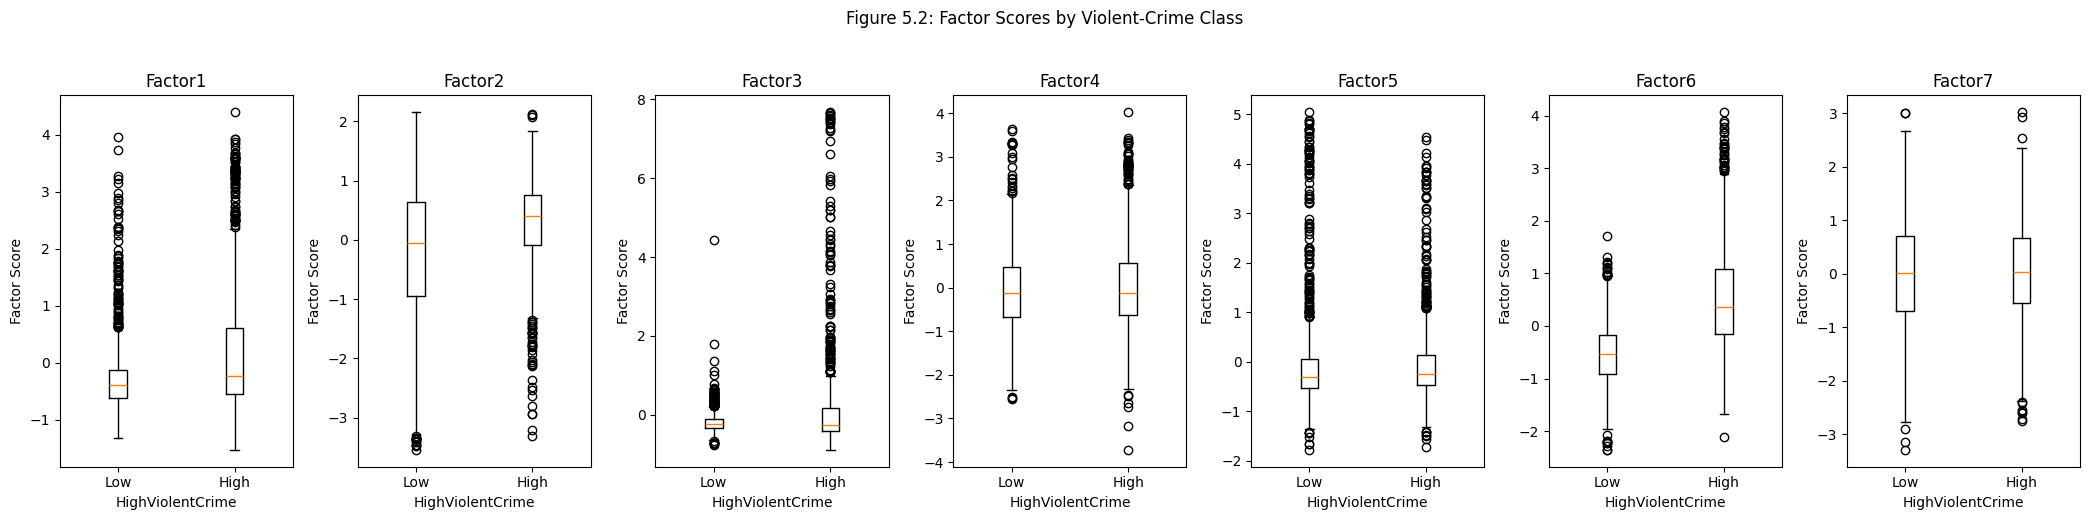

In [29]:
import matplotlib.pyplot as plt

# Figure 5.2: Factor scores by HighViolentCrime
plot_df = final_scores.copy()
plot_df["HighViolentCrime"] = df["HighViolentCrime"].values

n_factors = final_scores.shape[1]
fig, axes = plt.subplots(1, n_factors, figsize=(3 * n_factors, 5), sharey=False)

for i, factor_col in enumerate(final_scores.columns):
    low_values = plot_df[plot_df["HighViolentCrime"] == "Low"][factor_col]
    high_values = plot_df[plot_df["HighViolentCrime"] == "High"][factor_col]
    
    axes[i].boxplot(
        [low_values, high_values],
        tick_labels=["Low", "High"]
    )
    
    axes[i].set_title(factor_col)
    axes[i].set_xlabel("HighViolentCrime")
    axes[i].set_ylabel("Factor Score")

plt.suptitle("Figure 5.2: Factor Scores by Violent-Crime Class", y=1.03)
plt.tight_layout()
plt.show()

In [30]:
factor_score_comparison = []

for factor in final_scores.columns:
    low_scores = plot_df[plot_df["HighViolentCrime"] == "Low"][factor]
    high_scores = plot_df[plot_df["HighViolentCrime"] == "High"][factor]
    
    factor_score_comparison.append({
        "Factor": factor,
        "Low Mean": low_scores.mean(),
        "High Mean": high_scores.mean(),
        "Mean Difference: High - Low": high_scores.mean() - low_scores.mean(),
        "Low Median": low_scores.median(),
        "High Median": high_scores.median(),
        "Median Difference: High - Low": high_scores.median() - low_scores.median()
    })

factor_score_comparison = pd.DataFrame(factor_score_comparison)

factor_score_comparison["Abs Mean Difference"] = (
    factor_score_comparison["Mean Difference: High - Low"].abs()
)

factor_score_comparison_sorted = factor_score_comparison.sort_values(
    "Abs Mean Difference",
    ascending=False
)

factor_score_comparison_sorted.round(3)

,Factor,Low Mean,High Mean,Mean Difference: High - Low,Low Median,High Median,Median Difference: High - Low,Abs Mean Difference
5,Factor6,-0.535,0.540,1.075,-0.536,0.355,0.891,1.075
1,Factor2,-0.264,0.267,0.531,-0.051,0.396,0.447,0.531
0,Factor1,-0.233,0.234,0.467,-0.387,-0.239,0.148,0.467
2,Factor3,-0.184,0.185,0.369,-0.231,-0.248,-0.018,0.369
6,Factor7,-0.026,0.026,0.052,0.020,0.039,0.020,0.052
3,Factor4,-0.024,0.024,0.047,-0.116,-0.112,0.004,0.047
4,Factor5,0.022,-0.023,-0.045,-0.303,-0.238,0.065,0.045


Figure 5.2 and the factor-score comparison table show that the strongest separation between low and high violent-crime communities occurs on **Factor 6**. High violent-crime communities have a mean Factor 6 score of 0.540, while low violent-crime communities have a mean score of -0.535, giving a mean difference of 1.075. Since Factor 6 represents family structure / community composition, this is the factor most strongly associated with `HighViolentCrime`.

The next largest differences occur for **Factor 2** and **Factor 1**. Factor 2 has a mean difference of 0.531 and represents the income / housing-value dimension, while Factor 1 has a mean difference of 0.467 and represents immigration / language composition. Factor 3, the urban size / concentrated-disadvantage factor, shows a smaller mean difference of 0.369. Factors 4, 5, and 7 show very small mean differences, suggesting weaker separation between low and high violent-crime communities along household-size, youth-composition, and older/retirement dimensions.

### 5.7 Factor Analysis Summary and Use in Later Sections

Factor analysis produced a 7-factor varimax solution from the 100 standardized predictors. The interpreted factors are immigration/language composition, income/housing value, urban size/concentrated disadvantage, household size/occupancy, youth/young-adult composition, family structure/community composition, and older/retirement/residential stability.

The strongest class separation appears for **Factor 6**, the family-structure/community-composition factor, with a mean score difference of **1.075** between high and low violent-crime communities. Smaller but still notable differences appear for **Factor 2** (income/housing value, difference = **0.531**), **Factor 1** (immigration/language composition, difference = **0.467**), and **Factor 3** (urban size/concentrated disadvantage, difference = **0.369**).

The factor scores will be used alongside PCA scores as alternative lower-dimensional inputs for clustering, Gaussian mixture models, and classification. The factor labels are working interpretations of loading patterns, not causal explanations or fixed ground-truth categories.

## 6. CCA: Association Between Variable Blocks

### 6.1 CCA Setup and Block Definitions

CCA is used to study the association between two focused blocks of community-level predictors. To keep the analysis interpretable, the report uses one primary block pairing rather than testing many possible combinations.

Block X contains socioeconomic and education variables. Block Y contains housing, family-structure, and urbanization variables. This pairing asks how economic and education conditions are associated with residential stability, family structure, and urban density. Sensitive demographic variables are not used as a central CCA block.

In [31]:
from sklearn.preprocessing import StandardScaler

# Block X: Socioeconomic / education variables
cca_x_vars = [
    "medIncome",
    "perCapInc",
    "PctPopUnderPov",
    "PctUnemployed",
    "PctNotHSGrad",
    "PctBSorMore",
    "pctWPubAsst"
]

# Block Y: Housing / family / urbanization variables
cca_y_vars = [
    "PctHousOwnOcc",
    "PctPersOwnOccup",
    "PctVacantBoarded",
    "PctHousNoPhone",
    "PctKids2Par",
    "PctFam2Par",
    "TotalPctDiv",
    "PopDens"
]

X_cca_raw = df[cca_x_vars]
Y_cca_raw = df[cca_y_vars]

X_cca = pd.DataFrame(
    StandardScaler().fit_transform(X_cca_raw),
    columns=cca_x_vars,
    index=df.index
)

Y_cca = pd.DataFrame(
    StandardScaler().fit_transform(Y_cca_raw),
    columns=cca_y_vars,
    index=df.index
)

cca_setup_summary = pd.DataFrame({
    "Block": [
        "X: Socioeconomic / Education",
        "Y: Housing / Family / Urbanization"
    ],
    "Number of Variables": [
        X_cca.shape[1],
        Y_cca.shape[1]
    ],
    "Number of Observations": [
        X_cca.shape[0],
        Y_cca.shape[0]
    ],
    "Variables": [
        ", ".join(cca_x_vars),
        ", ".join(cca_y_vars)
    ]
})

cca_setup_summary

,Block,Number of Variables,Number of Observations,Variables
0,X: Socioeconomic / Education,7,1994,"medIncome, perCapInc, PctPopUnderPov, PctUnemployed, PctNotHSGrad, PctBSorMore, pctWPubAsst"
1,Y: Housing / Family / Urbanization,8,1994,"PctHousOwnOcc, PctPersOwnOccup, PctVacantBoarded, PctHousNoPhone, PctKids2Par, PctFam2Par, TotalPctDiv, PopDens"


The CCA setup uses 7 variables in Block X and 8 variables in Block Y, with 1,994 observations. Both blocks are standardized before fitting CCA so that the canonical variates are not driven by differences in variable scale.

### 6.2 Canonical Correlations

Table 6.1 shows that the first canonical pair has a very high canonical correlation of **0.927**, indicating a strong linear association between the socioeconomic/education block and the housing/family/urbanization block. The second and third canonical pairs also show moderate-to-strong associations, with correlations of **0.712** and **0.572**, while later pairs decline substantially. Interpretation therefore focuses mainly on the first canonical pair, with the second pair used only if its loadings provide a distinct and meaningful pattern.

In [32]:
from sklearn.cross_decomposition import CCA

# Number of canonical pairs is limited by the smaller block
n_cca_components = min(X_cca.shape[1], Y_cca.shape[1])

# Fit CCA
cca = CCA(n_components=n_cca_components, max_iter=1000)
X_c, Y_c = cca.fit_transform(X_cca, Y_cca)

# Compute canonical correlations
canonical_correlations = []

for i in range(n_cca_components):
    corr = np.corrcoef(X_c[:, i], Y_c[:, i])[0, 1]
    canonical_correlations.append(corr)

canonical_corr_table = pd.DataFrame({
    "Canonical Pair": [f"Pair {i+1}" for i in range(n_cca_components)],
    "Canonical Correlation": canonical_correlations
})

canonical_corr_table.round(3)

,Canonical Pair,Canonical Correlation
0,Pair 1,0.927
1,Pair 2,0.712
2,Pair 3,0.572
3,Pair 4,0.385
4,Pair 5,0.311
5,Pair 6,0.141
6,Pair 7,0.051


### 6.3 Canonical Loadings

Canonical loadings are correlations between the original variables and the canonical variates. They are used for interpretation because they are usually clearer than the raw CCA weights.

Table 6.2a reports the loadings for Block X, the socioeconomic and education variables. For Pair 1, the strongest positive loadings are `PctPopUnderPov` (0.968), `pctWPubAsst` (0.843), `PctNotHSGrad` (0.821), and `PctUnemployed` (0.810). The strongest negative loadings are `medIncome` (-0.839), `perCapInc` (-0.741), and `PctBSorMore` (-0.529). This indicates that the first Block X canonical variate represents an economic disadvantage / lower education gradient.

Table 6.2b reports the loadings for Block Y, the housing, family-structure, and urbanization variables. For Pair 1, the strongest positive loadings are `PctHousNoPhone` (0.918), `PctVacantBoarded` (0.529), and `TotalPctDiv` (0.521). The strongest negative loadings are `PctKids2Par` (-0.873), `PctFam2Par` (-0.848), `PctPersOwnOccup` (-0.690), and `PctHousOwnOcc` (-0.618). This indicates that the first Block Y canonical variate represents lower family stability, lower owner-occupied housing, and greater housing disadvantage.

Together, the first canonical pair shows that the economic disadvantage / lower education pattern in Block X is strongly associated with the housing disadvantage / family-structure pattern in Block Y. This matches the high first canonical correlation of 0.927. The second canonical pair is less central because its loadings are weaker and harder to label.

In [33]:
# Convert canonical variates to DataFrames
X_c_df = pd.DataFrame(
    X_c,
    columns=[f"X_CV{i+1}" for i in range(n_cca_components)],
    index=df.index
)

Y_c_df = pd.DataFrame(
    Y_c,
    columns=[f"Y_CV{i+1}" for i in range(n_cca_components)],
    index=df.index
)

# Compute canonical loadings for the first two canonical pairs
x_loadings = pd.DataFrame(index=cca_x_vars)
y_loadings = pd.DataFrame(index=cca_y_vars)

for i in range(2):
    x_loadings[f"Pair {i+1} X Loading"] = [
        np.corrcoef(X_cca[var], X_c_df[f"X_CV{i+1}"])[0, 1]
        for var in cca_x_vars
    ]
    
    y_loadings[f"Pair {i+1} Y Loading"] = [
        np.corrcoef(Y_cca[var], Y_c_df[f"Y_CV{i+1}"])[0, 1]
        for var in cca_y_vars
    ]

x_loadings = x_loadings.sort_values(
    by="Pair 1 X Loading",
    key=lambda col: col.abs(),
    ascending=False
)

y_loadings = y_loadings.sort_values(
    by="Pair 1 Y Loading",
    key=lambda col: col.abs(),
    ascending=False
)

In [34]:
x_loadings.round(3)

,Pair 1 X Loading,Pair 2 X Loading
PctPopUnderPov,0.968,-0.035
pctWPubAsst,0.843,-0.010
medIncome,-0.839,0.366
PctNotHSGrad,0.821,0.299
PctUnemployed,0.810,0.104
perCapInc,-0.741,0.090
PctBSorMore,-0.529,-0.037


In [35]:
y_loadings.round(3)

,Pair 1 Y Loading,Pair 2 Y Loading
PctHousNoPhone,0.918,0.066
PctKids2Par,-0.873,0.222
PctFam2Par,-0.848,0.363
PctPersOwnOccup,-0.690,0.369
PctHousOwnOcc,-0.618,0.439
PctVacantBoarded,0.529,0.093
TotalPctDiv,0.521,-0.532
PopDens,0.126,0.082


### 6.4 Canonical Score Plot

Figure 6.1 plots the first canonical variate from Block X against the first canonical variate from Block Y. The strong diagonal pattern reflects the high first canonical correlation of 0.927. Based on the loadings in Table 6.2a, the Block X variate represents higher poverty, public assistance, unemployment, and lower educational attainment, contrasted with lower income and lower bachelor’s degree attainment. Based on Table 6.2b, the Block Y variate represents greater housing disadvantage and family-structure instability, including higher `PctHousNoPhone`, `PctVacantBoarded`, and `TotalPctDiv`, contrasted with lower `PctKids2Par`, `PctFam2Par`, `PctPersOwnOccup`, and `PctHousOwnOcc`.

In the score plot, high violent-crime communities are more concentrated toward the upper-right region, where both canonical variates are higher. This suggests that communities scoring higher on the economic disadvantage / lower education pattern also tend to score higher on the housing disadvantage / family-structure pattern, and that this combined cross-block pattern is associated with `HighViolentCrime`. The crime label was used only for coloring the plot, not for fitting the CCA model.

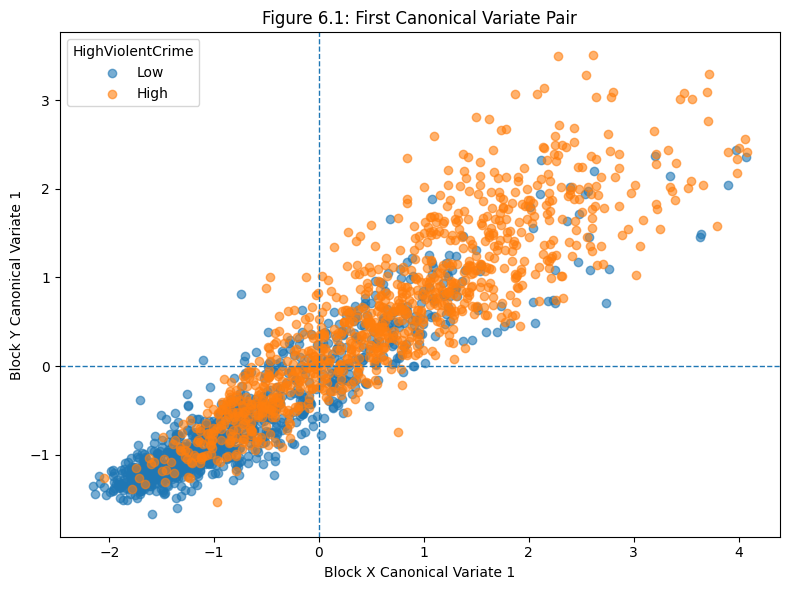

In [36]:
# Create plotting dataframe for first canonical pair
cca_plot_df = pd.DataFrame({
    "Block X Canonical Variate 1": X_c[:, 0],
    "Block Y Canonical Variate 1": Y_c[:, 0],
    "HighViolentCrime": df["HighViolentCrime"].values
})

plt.figure(figsize=(8, 6))

for label in ["Low", "High"]:
    subset = cca_plot_df[cca_plot_df["HighViolentCrime"] == label]
    plt.scatter(
        subset["Block X Canonical Variate 1"],
        subset["Block Y Canonical Variate 1"],
        alpha=0.6,
        label=label
    )

plt.axhline(0, linestyle="--", linewidth=1)
plt.axvline(0, linestyle="--", linewidth=1)

plt.title("Figure 6.1: First Canonical Variate Pair")
plt.xlabel("Block X Canonical Variate 1")
plt.ylabel("Block Y Canonical Variate 1")
plt.legend(title="HighViolentCrime")
plt.tight_layout()
plt.show()

### 6.5 CCA Summary

CCA identified a strong first cross-block association between socioeconomic/education variables and housing/family/urbanization variables. The first canonical correlation was 0.927, with Block X reflecting higher poverty, public assistance, unemployment, and lower education/income, and Block Y reflecting housing disadvantage, lower owner-occupied housing, and lower two-parent family structure.

This cross-block pattern also aligned with `HighViolentCrime` in the canonical score plot, although the crime label was not used to fit the CCA model. The result is interpreted as an aggregate association between variable blocks, not as prediction or causation.

## 7. Clustering: Hard Community Profiles

Clustering is used to group communities with similar multivariate characteristics. Because the original predictor space contains 100 variables with substantial correlation, clustering is performed on retained PCA scores rather than the raw predictors. This lower-dimensional representation keeps the main shared structure while making distance-based clustering more stable and easier to interpret.

The clusters are interpreted as exploratory community profiles. They are not treated as ground-truth categories or causal groups.

### 7.1 Clustering Input and Distance Choice

The clustering input is the retained PCA score matrix. Specifically, the analysis uses the first PCs needed to reach approximately 80% cumulative variance explained. This gives a compact representation of the predictor space while preserving most of the multivariate variation.

Euclidean distance is used for clustering because both K-means and Ward hierarchical clustering are based on squared-distance geometry. The same PCA-score input is used for both methods so that the resulting cluster solutions are comparable.

In [37]:
# Clustering input setup: retained PCA scores

# Number of PCs needed to reach at least 80% cumulative variance
n_pcs_clustering = pcs_for_80

# Retained PCA score matrix for clustering
cluster_input = pca_scores_df.iloc[:, :n_pcs_clustering].copy()

# Summary table
cluster_input_summary = pd.DataFrame({
    "Input Representation": ["Retained PCA scores"],
    "Distance Geometry": ["Euclidean"],
    "Number of Observations": [cluster_input.shape[0]],
    "Number of Features": [cluster_input.shape[1]],
    "Selection Rule": ["Minimum PCs needed to reach 80% cumulative variance"],
    "Cumulative Variance Explained": [cumulative_variance[n_pcs_clustering - 1]]
})

cluster_input_summary.round(3)

,Input Representation,Distance Geometry,Number of Observations,Number of Features,Selection Rule,Cumulative Variance Explained
0,Retained PCA scores,Euclidean,1994,11,Minimum PCs needed to reach 80% cumulative variance,0.8


The clustering input consists of the first 11 PCA scores, which together explain approximately 80% of the total predictor variance. This reduces the original 100-dimensional predictor space to a compact representation while retaining most of the shared multivariate structure. The same retained PCA-score matrix is used for both K-means and hierarchical clustering, making the two hard-clustering methods directly comparable.

### 7.2 K-Means Clustering

K-means clustering partitions communities into a fixed number of clusters, \(K\), by minimizing within-cluster variation. The analysis fits K-means models over a range of possible \(K\) values and evaluates them using two diagnostics:

1. **Elbow plot:** shows how within-cluster sum of squares decreases as \(K\) increases.
2. **Silhouette score:** measures how well-separated the clusters are on average.

The final value of \(K\) is chosen by balancing compactness, separation, and interpretability.

In [40]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import pandas as pd
import os

os.environ["OMP_NUM_THREADS"] = "8"
os.environ["LOKY_MAX_CPU_COUNT"] = "8"

# Candidate K values
k_values = range(2, 21)

kmeans_results = []

for k in k_values:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )
    
    cluster_labels = kmeans.fit_predict(cluster_input)
    
    kmeans_results.append({
        "K": k,
        "Within-Cluster Sum of Squares": kmeans.inertia_,
        "Silhouette Score": silhouette_score(cluster_input, cluster_labels)
    })

kmeans_results_table = pd.DataFrame(kmeans_results)

kmeans_results_table.round(3)

,K,Within-Cluster Sum of Squares,Silhouette Score
0,2,124926.633,0.208
1,3,105420.347,0.229
2,4,95894.843,0.160
3,5,86670.698,0.177
4,6,78423.867,0.197
5,7,72795.052,0.198
6,8,68365.195,0.175
7,9,64773.500,0.174
8,10,61563.593,0.188
9,11,59244.060,0.177


### 7.3 Choosing the Number of K-Means Clusters

The elbow and silhouette plots are used together to select the number of clusters. A good choice of \(K\) should reduce within-cluster variation substantially without creating too many small or hard-to-interpret clusters. The silhouette score provides an additional check by measuring whether communities are closer to their own cluster than to other clusters.

[Insert Figure 7.1: K-Means Elbow Plot]

[Insert Figure 7.2: Average Silhouette Score]

[Write selected K and justification here.]

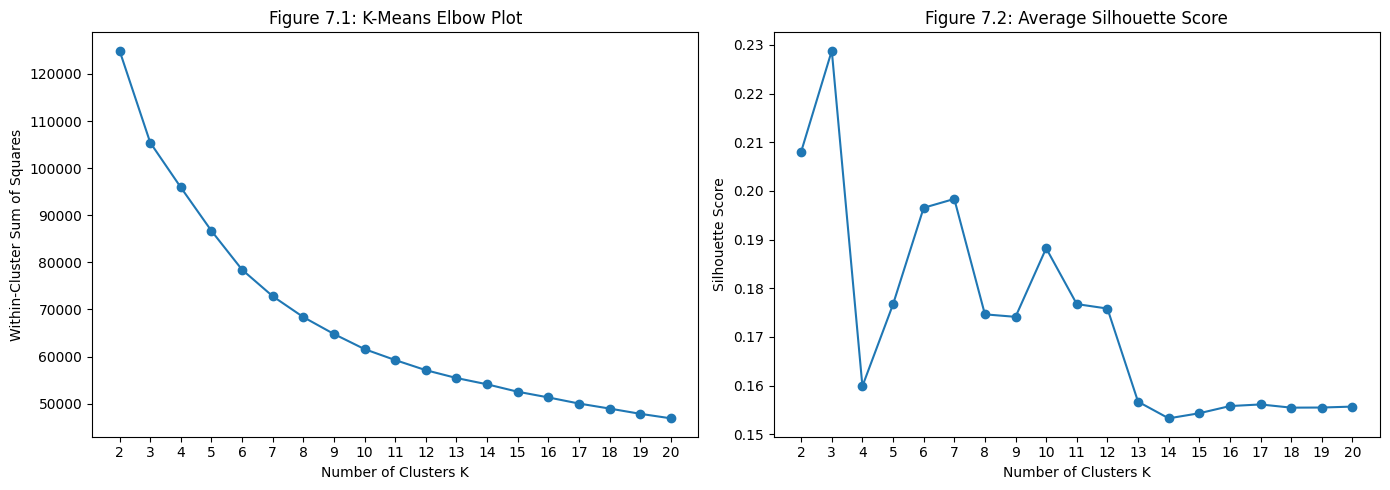

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Figure 7.1: Elbow plot
axes[0].plot(
    kmeans_results_table["K"],
    kmeans_results_table["Within-Cluster Sum of Squares"],
    marker="o"
)

axes[0].set_title("Figure 7.1: K-Means Elbow Plot")
axes[0].set_xlabel("Number of Clusters K")
axes[0].set_ylabel("Within-Cluster Sum of Squares")
axes[0].set_xticks(kmeans_results_table["K"])

# Figure 7.2: Silhouette plot
axes[1].plot(
    kmeans_results_table["K"],
    kmeans_results_table["Silhouette Score"],
    marker="o"
)

axes[1].set_title("Figure 7.2: Average Silhouette Score")
axes[1].set_xlabel("Number of Clusters K")
axes[1].set_ylabel("Silhouette Score")
axes[1].set_xticks(kmeans_results_table["K"])

plt.tight_layout()
plt.show()

Figures 7.1 and 7.2 evaluate K-means clustering across \(K = 2\) through \(K = 20\). The within-cluster sum of squares decreases steadily as \(K\) increases, but there is no strong later elbow that clearly supports a larger number of clusters. The silhouette score is highest at \(K = 3\), indicating that the three-cluster solution has the best average separation among the tested values.

Based on these diagnostics, the final K-means model uses **K = 3**. Because the silhouette scores are modest overall, the clusters are interpreted as broad exploratory community profiles rather than sharply separated natural groups.

### 7.4 Final K-Means Cluster Profiles

After selecting \(K\), the final K-means model is fit using the retained PCA scores. Each community is assigned to one cluster. The resulting clusters are profiled using:

- number of communities in each cluster,
- mean values of selected PC scores,
- mean `ViolentCrimesPerPop`,
- proportion of communities labeled `HighViolentCrime`.

This profile table is used to describe each cluster as a community type based on its multivariate characteristics and crime outcome summaries.

[Insert Table 7.1: K-Means Cluster Profile Table]

In [42]:
from sklearn.cluster import KMeans
import pandas as pd

# Final K-means model
selected_k = 3

final_kmeans = KMeans(
    n_clusters=selected_k,
    random_state=42,
    n_init=20
)

kmeans_labels = final_kmeans.fit_predict(cluster_input)

# Create clustering results dataframe
kmeans_cluster_df = pca_scores_df.copy()
kmeans_cluster_df["KMeans Cluster"] = kmeans_labels
kmeans_cluster_df["ViolentCrimesPerPop"] = df["ViolentCrimesPerPop"].values
kmeans_cluster_df["HighViolentCrime"] = df["HighViolentCrime"].values

# Convert High/Low label to numeric indicator for cluster summaries
kmeans_cluster_df["HighViolentCrime Indicator"] = (
    kmeans_cluster_df["HighViolentCrime"] == "High"
).astype(int)

# Cluster profile table using first 4 PCs for interpretation
pc_profile_cols = ["PC1", "PC2", "PC3", "PC4"]

kmeans_profile_table = (
    kmeans_cluster_df
    .groupby("KMeans Cluster")
    .agg(
        Number_of_Communities=("KMeans Cluster", "size"),
        Mean_ViolentCrimesPerPop=("ViolentCrimesPerPop", "mean"),
        Proportion_HighViolentCrime=("HighViolentCrime Indicator", "mean"),
        Mean_PC1=("PC1", "mean"),
        Mean_PC2=("PC2", "mean"),
        Mean_PC3=("PC3", "mean"),
        Mean_PC4=("PC4", "mean")
    )
    .reset_index()
)

# Sort clusters from lowest to highest average violent crime for easier interpretation
kmeans_profile_table = kmeans_profile_table.sort_values(
    "Mean_ViolentCrimesPerPop"
).reset_index(drop=True)

kmeans_profile_table.round(3)

,KMeans Cluster,Number_of_Communities,Mean_ViolentCrimesPerPop,Proportion_HighViolentCrime,Mean_PC1,Mean_PC2,Mean_PC3,Mean_PC4
0,1,793,0.105,0.206,5.035,0.215,0.237,0.270
1,0,979,0.295,0.641,-3.024,-1.996,-0.571,-0.513
2,2,222,0.464,0.910,-4.649,8.034,1.673,1.297


Table 7.1 shows clear differences in violent-crime outcomes across the three K-means clusters. Cluster 1 has the lowest average `ViolentCrimesPerPop` at 0.105 and only 20.6% of communities are classified as high violent-crime communities. This cluster has a strongly positive mean PC1 score, suggesting higher economic advantage and family stability based on the earlier PCA interpretation.

Cluster 0 has an intermediate profile, with mean `ViolentCrimesPerPop` of 0.295 and 64.1% high violent-crime communities. Its negative PC1 score suggests lower economic advantage/family stability than Cluster 1, while its negative PC2 score indicates a different immigration/language composition profile than the high-crime cluster.

Cluster 2 has the highest average `ViolentCrimesPerPop` at 0.464 and 91.0% of communities are classified as high violent-crime communities. This cluster has a strongly negative PC1 score and a very high positive PC2 score, suggesting that it combines lower economic advantage/family stability with a distinct immigration/language composition pattern. Because clustering is unsupervised, these differences are interpreted as descriptive associations between community profiles and crime outcomes, not causal effects.

### 7.5 K-Means Cluster Visualization

The final K-means clusters are visualized in the PC1–PC2 score space. This plot shows how the cluster assignments relate to the first two PCA dimensions and whether clusters occupy distinct regions of the low-dimensional predictor space.

[Insert Figure 7.3: K-Means Clusters in PC Space]

[Write cluster interpretation here.]

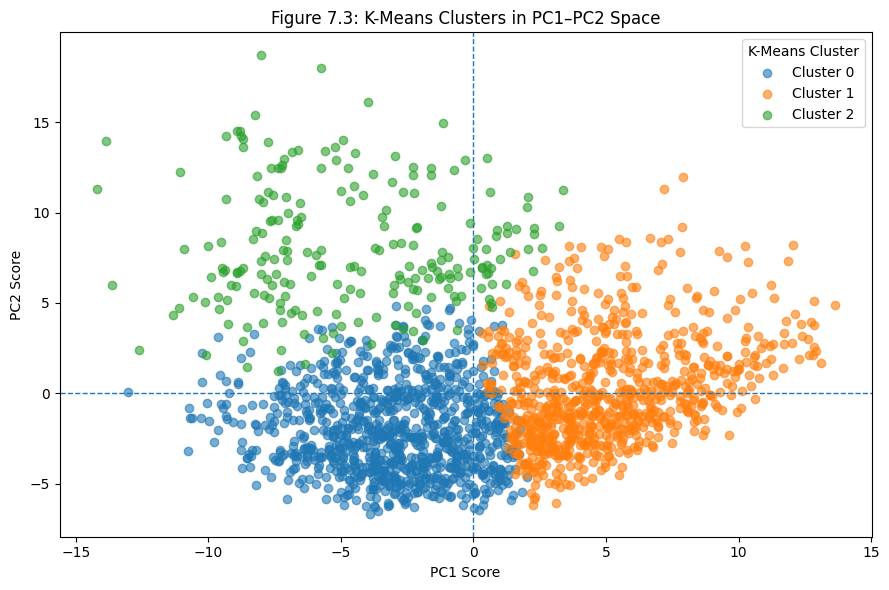

In [43]:
# PC-space visualization dataframe
kmeans_plot_df = kmeans_cluster_df[["PC1", "PC2", "KMeans Cluster"]].copy()

plt.figure(figsize=(9, 6))

for cluster in sorted(kmeans_plot_df["KMeans Cluster"].unique()):
    subset = kmeans_plot_df[kmeans_plot_df["KMeans Cluster"] == cluster]
    plt.scatter(
        subset["PC1"],
        subset["PC2"],
        alpha=0.6,
        label=f"Cluster {cluster}"
    )

plt.axhline(0, linestyle="--", linewidth=1)
plt.axvline(0, linestyle="--", linewidth=1)

plt.title("Figure 7.3: K-Means Clusters in PC1–PC2 Space")
plt.xlabel("PC1 Score")
plt.ylabel("PC2 Score")
plt.legend(title="K-Means Cluster")
plt.tight_layout()
plt.show()

Figure 7.3 shows the final K-means cluster assignments in PC1–PC2 space. The clusters separate mainly along the first two PCA dimensions. Cluster 1 is concentrated on the positive side of PC1, matching the lower-crime profile from Table 7.1. Cluster 0 occupies the lower PC2 and mostly negative PC1 region, corresponding to the intermediate-crime profile. Cluster 2 is concentrated at high positive PC2 values and has the highest mean violent-crime rate and highest proportion of high violent-crime communities.

The clusters are not perfectly separated, which is consistent with the modest silhouette scores. They should therefore be interpreted as broad exploratory community profiles rather than sharply defined natural groups.

### 7.6 Hierarchical Clustering

Hierarchical clustering is fit using Ward linkage on the same retained PCA-score matrix used for K-means. This keeps the two clustering approaches comparable because both use the same lower-dimensional input representation and Euclidean distance geometry. The linkage object created here is used to produce the dendrogram in the next step.

In [44]:
from scipy.cluster.hierarchy import linkage

# Hierarchical clustering using Ward linkage on retained PCA scores
hierarchical_linkage = linkage(
    cluster_input,
    method="ward"
)

hierarchical_summary = pd.DataFrame({
    "Input Representation": ["Retained PCA scores"],
    "Linkage Method": ["Ward"],
    "Distance Geometry": ["Euclidean"],
    "Number of Observations": [cluster_input.shape[0]],
    "Number of Features": [cluster_input.shape[1]]
})

hierarchical_summary

,Input Representation,Linkage Method,Distance Geometry,Number of Observations,Number of Features
0,Retained PCA scores,Ward,Euclidean,1994,11


### 7.7 Hierarchical Clustering Dendrogram

Figure 7.4 shows the Ward hierarchical clustering dendrogram using the retained PCA scores. Because the dataset contains 1,994 communities, the dendrogram is truncated to display the highest-level merging structure rather than every individual observation. Each x-axis leaf represents a collapsed subgroup, with the number in parentheses showing how many communities it contains.

The largest merge heights occur near the top of the dendrogram, indicating that the data can be summarized by a small number of broad clusters. For comparability with the K-means solution, the dendrogram is cut to produce three hierarchical clusters.

This three-cluster cut produces groups of 868, 984, and 142 communities. The first two clusters are large broad profiles, while the smaller third cluster likely represents a more distinct community profile.

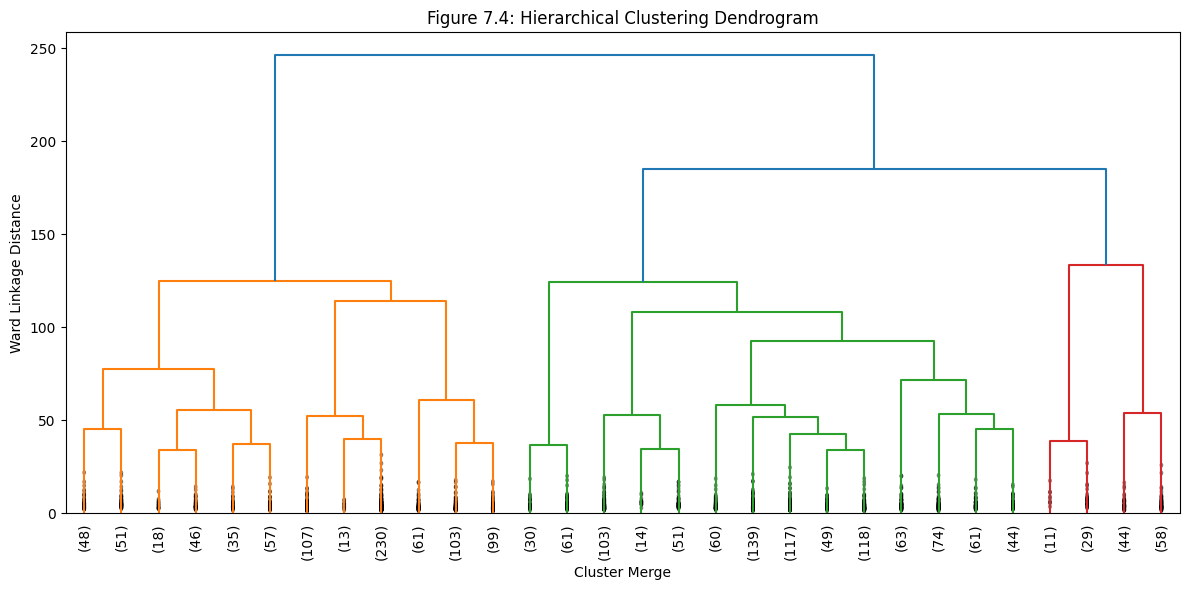

In [45]:
from scipy.cluster.hierarchy import dendrogram
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

dendrogram(
    hierarchical_linkage,
    truncate_mode="lastp",   # show only the last merged clusters
    p=30,                    # show last 30 merged clusters
    leaf_rotation=90,
    leaf_font_size=10,
    show_contracted=True
)

plt.title("Figure 7.4: Hierarchical Clustering Dendrogram")
plt.xlabel("Cluster Merge")
plt.ylabel("Ward Linkage Distance")
plt.tight_layout()
plt.show()

In [46]:
from scipy.cluster.hierarchy import fcluster

selected_hierarchical_k = 3

hierarchical_labels = fcluster(
    hierarchical_linkage,
    t=selected_hierarchical_k,
    criterion="maxclust"
)

hierarchical_cluster_counts = pd.Series(
    hierarchical_labels
).value_counts().sort_index()

hierarchical_cluster_counts

1    868
2    984
3    142
Name: count, dtype: int64

### 7.8 Hierarchical Cluster Profiles

Table 7.2 profiles the three hierarchical clusters using the same summaries as the K-means cluster table. The clusters are sorted by average `ViolentCrimesPerPop`, so they move from the lowest-crime profile to the highest-crime profile.

Hierarchical Cluster 1 contains 868 communities and has the lowest mean `ViolentCrimesPerPop` at 0.122, with 25.8% classified as high violent-crime communities. Its positive mean PC1 score suggests a higher economic advantage / family stability profile.

Hierarchical Cluster 2 contains 984 communities and has an intermediate mean `ViolentCrimesPerPop` of 0.300, with 64.4% high violent-crime communities. Its negative PC1 and PC2 scores suggest lower economic advantage / family stability and a different immigration/language composition profile.

Hierarchical Cluster 3 contains 142 communities and has the highest mean `ViolentCrimesPerPop` at 0.519, with 95.1% high violent-crime communities. Its strongly negative PC1 and high positive PC2, PC3, and PC4 scores suggest a distinct high-crime profile in the PCA space.

Overall, the hierarchical solution closely mirrors the K-means result: both methods identify lower-, intermediate-, and higher-crime community profiles, although the exact cluster sizes differ because the algorithms form clusters differently.

In [47]:
# Hierarchical cluster profile table

hierarchical_cluster_df = pca_scores_df.copy()
hierarchical_cluster_df["Hierarchical Cluster"] = hierarchical_labels
hierarchical_cluster_df["ViolentCrimesPerPop"] = df["ViolentCrimesPerPop"].values
hierarchical_cluster_df["HighViolentCrime"] = df["HighViolentCrime"].values

hierarchical_cluster_df["HighViolentCrime Indicator"] = (
    hierarchical_cluster_df["HighViolentCrime"] == "High"
).astype(int)

hierarchical_profile_table = (
    hierarchical_cluster_df
    .groupby("Hierarchical Cluster")
    .agg(
        Number_of_Communities=("Hierarchical Cluster", "size"),
        Mean_ViolentCrimesPerPop=("ViolentCrimesPerPop", "mean"),
        Proportion_HighViolentCrime=("HighViolentCrime Indicator", "mean"),
        Mean_PC1=("PC1", "mean"),
        Mean_PC2=("PC2", "mean"),
        Mean_PC3=("PC3", "mean"),
        Mean_PC4=("PC4", "mean")
    )
    .reset_index()
)

# Sort from lowest to highest average violent crime
hierarchical_profile_table = hierarchical_profile_table.sort_values(
    "Mean_ViolentCrimesPerPop"
).reset_index(drop=True)

hierarchical_profile_table.round(3)

,Hierarchical Cluster,Number_of_Communities,Mean_ViolentCrimesPerPop,Proportion_HighViolentCrime,Mean_PC1,Mean_PC2,Mean_PC3,Mean_PC4
0,1,868,0.122,0.258,4.364,0.496,0.512,0.133
1,2,984,0.300,0.644,-2.934,-1.684,-0.755,-0.386
2,3,142,0.519,0.951,-6.343,8.635,2.100,1.865


### 7.9 Clustering Summary

Both clustering methods identified three broad community profiles in the retained PCA space: a lower-crime profile, an intermediate-crime profile, and a higher-crime profile. The K-means solution selected \(K = 3\) based on the highest silhouette score, while the Ward hierarchical solution was cut into three clusters for comparison.

The two methods produced similar patterns. In both cases, the lowest-crime cluster had positive mean PC1 scores, corresponding to higher economic advantage / family stability. The highest-crime cluster had strongly negative PC1 scores and high positive PC2 scores, indicating a distinct profile with lower economic advantage / family stability and a different immigration/language composition pattern.

These clusters are exploratory summaries, not ground-truth community types. Differences in average `ViolentCrimesPerPop` and `HighViolentCrime` proportions across clusters describe associations between multivariate community profiles and violent-crime outcomes, not causal effects.

## 8. Gaussian Mixture Models: Probabilistic Community Profiles

Gaussian Mixture Models are used to model communities as coming from a mixture of latent Gaussian components. Unlike K-means, which gives hard cluster assignments, GMM estimates posterior membership probabilities for each community. This allows communities near component boundaries to have uncertain membership.

The GMM analysis uses the same retained PCA-score matrix used in Section 7 so that the probabilistic components can be compared directly with the K-means clusters.

### 8.1 GMM Input and Model Setup

The GMM is fit on the retained PCA scores used for clustering. Candidate models are fit across a range of component counts and covariance structures. This matters because the covariance structure controls component shape: spherical models impose round components, diagonal models allow axis-aligned ellipses, tied models share one covariance matrix across components, and full models allow each component to have its own covariance matrix.

In [48]:
# GMM input setup: same retained PCA scores used for clustering

gmm_input = cluster_input.copy()

component_values = range(2, 11)

covariance_types = [
    "spherical",
    "diag",
    "tied",
    "full"
]

gmm_setup_summary = pd.DataFrame({
    "Input Representation": ["Retained PCA scores"],
    "Number of Observations": [gmm_input.shape[0]],
    "Number of Features": [gmm_input.shape[1]],
    "Component Counts Tested": [f"{min(component_values)} to {max(component_values)}"],
    "Covariance Types Tested": [", ".join(covariance_types)]
})

gmm_setup_summary

,Input Representation,Number of Observations,Number of Features,Component Counts Tested,Covariance Types Tested
0,Retained PCA scores,1994,11,2 to 10,"spherical, diag, tied, full"


### 8.2 Choosing the Number of Components

Table 8.1 compares GMM candidates across component counts and covariance structures. The lowest BIC is achieved by the full-covariance model with 9 components. AIC continues to favor a slightly more complex 10-component full-covariance model, but BIC is used as the primary selection criterion because it penalizes model complexity more strongly.

Based on these results, the final GMM uses **9 components with full covariance**. This specification allows each component to have its own elliptical covariance structure while avoiding the additional complexity of the 10-component model preferred by AIC.

In [49]:
from sklearn.mixture import GaussianMixture
import pandas as pd

gmm_results = []

for covariance_type in covariance_types:
    for n_components in component_values:
        gmm = GaussianMixture(
            n_components=n_components,
            covariance_type=covariance_type,
            random_state=42,
            n_init=20
        )
        
        gmm.fit(gmm_input)
        
        gmm_results.append({
            "Covariance Type": covariance_type,
            "Number of Components": n_components,
            "BIC": gmm.bic(gmm_input),
            "AIC": gmm.aic(gmm_input)
        })

gmm_results_table = pd.DataFrame(gmm_results)

gmm_results_table_sorted = gmm_results_table.sort_values("BIC").reset_index(drop=True)

gmm_results_table_sorted.round(2)

,Covariance Type,Number of Components,BIC,AIC
0,full,9,85374.29,81450.17
1,full,8,85398.11,81910.62
2,full,7,85452.85,82402.00
3,full,10,85530.67,81169.91
4,full,6,85724.67,83110.45
5,full,5,85917.96,83740.38
6,full,4,86539.02,84798.07
7,full,3,87792.64,86488.33
8,tied,10,89744.74,88709.13
9,diag,10,89968.05,88686.13


### 8.3 Final GMM Fit and Soft Assignments

After selecting the final GMM specification, each community receives posterior membership probabilities across components. The most likely component is used for summary tables and visualization, while the maximum posterior probability is used to assess assignment certainty.

[Insert final GMM fit and responsibility summary here]

In [52]:
from sklearn.mixture import GaussianMixture
import pandas as pd
import numpy as np

# Final GMM specification selected from BIC
selected_gmm_components = 9
selected_gmm_covariance = "full"

final_gmm = GaussianMixture(
    n_components=selected_gmm_components,
    covariance_type=selected_gmm_covariance,
    random_state=42,
    n_init=20
)

# Fit final GMM
final_gmm.fit(gmm_input)

# Posterior probabilities / responsibilities: gamma_ik
gamma = final_gmm.predict_proba(gmm_input)

# Most likely component assignment
gmm_labels = gamma.argmax(axis=1)

# Assignment certainty
max_gamma = gamma.max(axis=1)

# Store GMM results
gmm_results_df = pca_scores_df.copy()
gmm_results_df["GMM Component"] = gmm_labels
gmm_results_df["Max Gamma"] = max_gamma
gmm_results_df["ViolentCrimesPerPop"] = df["ViolentCrimesPerPop"].values
gmm_results_df["HighViolentCrime"] = df["HighViolentCrime"].values

# Soft-assignment summary
gmm_certainty_summary = pd.DataFrame({
    "Number of Components": [selected_gmm_components],
    "Covariance Type": [selected_gmm_covariance],
    "Average Max Gamma": [max_gamma.mean()],
    "Median Max Gamma": [np.median(max_gamma)],
    "Minimum Max Gamma": [max_gamma.min()],
    "Proportion with Max Gamma >= 0.90": [(max_gamma >= 0.90).mean()],
    "Proportion with Max Gamma >= 0.75": [(max_gamma >= 0.75).mean()]
})

gmm_certainty_summary.round(3)

,Number of Components,Covariance Type,Average Max Gamma,Median Max Gamma,Minimum Max Gamma,Proportion with Max Gamma >= 0.90,Proportion with Max Gamma >= 0.75
0,9,full,0.918,0.983,0.275,0.746,0.877


The final GMM uses 9 full-covariance components. The average maximum posterior probability, $\gamma_{ik}$, is 0.918 and the median is 0.983, indicating that most communities are assigned to one component with high certainty. About 74.6% of communities have maximum $\gamma \geq 0.90$, and 87.7% have maximum $\gamma \geq 0.75$. However, the minimum maximum $\gamma$ is 0.275, showing that some communities lie near component boundaries and have uncertain membership.

This uncertainty is the main advantage of the GMM over hard clustering: instead of forcing every community into a single cluster with no uncertainty measure, the GMM provides posterior probabilities that quantify assignment confidence.

### 8.4 GMM Component Profiles

Table 8.2 profiles the final 9-component full-covariance GMM using the most likely component assignment for each community. Components are sorted from lowest to highest mean `ViolentCrimesPerPop`.

The lowest-crime components are Components 0 and 7, with mean violent-crime rates of 0.090 and 0.097 and high-crime proportions of 15.2% and 17.7%. Both have positive mean PC1 scores, especially Component 7, suggesting profiles with higher economic advantage / family stability.

The highest-crime components are Components 3, 2, and 1, with mean violent-crime rates of 0.366, 0.395, and 0.585. These components also have high proportions of `HighViolentCrime`, especially Components 3 and 1. They tend to have strongly negative PC1 scores and, in some cases, high positive PC2 scores, indicating profiles associated with lower economic advantage / family stability and distinct immigration/language composition patterns.

The GMM provides more detailed subgroups than the three-cluster K-means solution. Instead of only low-, middle-, and high-crime clusters, the GMM separates communities into multiple probabilistic profiles with different combinations of PC1–PC4 values and different levels of assignment certainty.

In [53]:
# GMM component profile table

gmm_results_df["HighViolentCrime Indicator"] = (
    gmm_results_df["HighViolentCrime"] == "High"
).astype(int)

gmm_component_profile = (
    gmm_results_df
    .groupby("GMM Component")
    .agg(
        Number_of_Communities=("GMM Component", "size"),
        Mean_Max_Gamma=("Max Gamma", "mean"),
        Mean_ViolentCrimesPerPop=("ViolentCrimesPerPop", "mean"),
        Proportion_HighViolentCrime=("HighViolentCrime Indicator", "mean"),
        Mean_PC1=("PC1", "mean"),
        Mean_PC2=("PC2", "mean"),
        Mean_PC3=("PC3", "mean"),
        Mean_PC4=("PC4", "mean")
    )
    .reset_index()
)

# Sort components from lowest to highest mean violent crime
gmm_component_profile = (
    gmm_component_profile
    .sort_values("Mean_ViolentCrimesPerPop")
    .reset_index(drop=True)
)

gmm_component_profile.round(3)

,GMM Component,Number_of_Communities,Mean_Max_Gamma,Mean_ViolentCrimesPerPop,Proportion_HighViolentCrime,Mean_PC1,Mean_PC2,Mean_PC3,Mean_PC4
0,0,428,0.892,0.090,0.152,3.752,-2.055,1.122,0.111
1,7,232,0.896,0.097,0.177,7.369,2.518,-0.596,1.104
2,4,157,0.889,0.164,0.401,1.574,0.652,-0.141,-2.948
3,5,225,0.925,0.171,0.422,-2.257,-4.498,0.685,0.156
4,6,229,0.926,0.263,0.629,0.386,0.590,-1.560,1.968
5,8,182,0.947,0.282,0.593,-3.645,-0.723,-2.071,-3.219
6,3,161,0.960,0.366,0.901,-3.519,6.749,4.326,0.113
7,2,230,0.924,0.395,0.826,-4.897,-2.359,0.572,-0.056
8,1,150,0.944,0.585,0.947,-5.248,4.382,-3.784,1.694


### 8.5 GMM Visualization in PC Space

Figure 8.2 visualizes the final 9-component GMM in PC1–PC2 space using each community’s most likely component assignment. The components show more overlap than the K-means clusters because the GMM was fit in the retained 11-dimensional PCA space, while this figure only displays the first two dimensions. Even so, several broad patterns are visible: some components occupy the positive-PC1, lower-crime region, while others occupy negative-PC1 or high-PC2 regions associated with higher violent-crime profiles in Table 8.2.

Compared with K-means, the GMM produces a more detailed partition of the PCA space. Rather than forcing communities into three broad clusters, it separates them into multiple probabilistic components with different PC-score profiles and different average crime outcomes. The overlap in the plot also reinforces the value of GMM soft assignments, since some communities lie near boundaries between components.

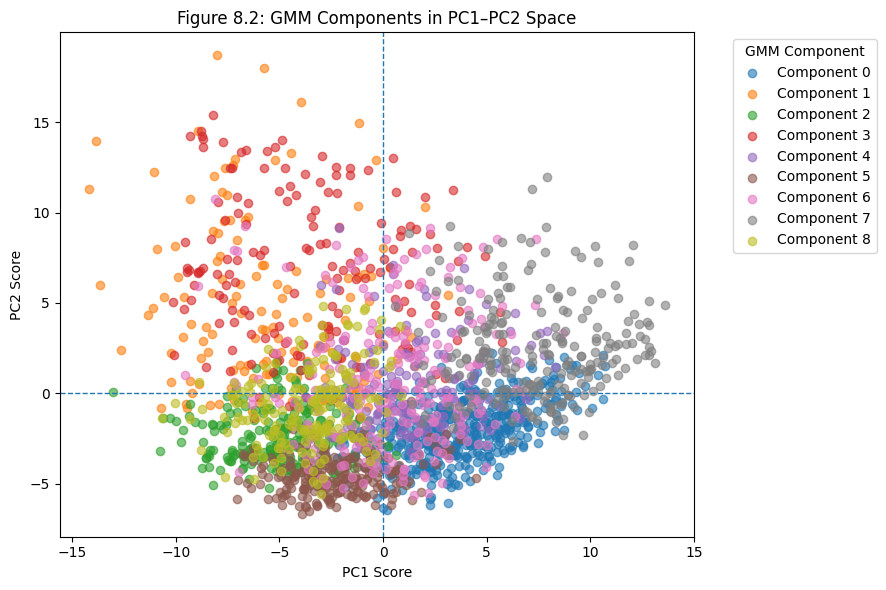

In [54]:
import matplotlib.pyplot as plt

# GMM component visualization in PC1-PC2 space
gmm_plot_df = gmm_results_df[["PC1", "PC2", "GMM Component"]].copy()

plt.figure(figsize=(9, 6))

for component in sorted(gmm_plot_df["GMM Component"].unique()):
    subset = gmm_plot_df[gmm_plot_df["GMM Component"] == component]
    
    plt.scatter(
        subset["PC1"],
        subset["PC2"],
        alpha=0.6,
        label=f"Component {component}"
    )

plt.axhline(0, linestyle="--", linewidth=1)
plt.axvline(0, linestyle="--", linewidth=1)

plt.title("Figure 8.2: GMM Components in PC1–PC2 Space")
plt.xlabel("PC1 Score")
plt.ylabel("PC2 Score")
plt.legend(title="GMM Component", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

### 8.6 GMM Summary

The GMM results are interpreted as probabilistic community profiles. Components are statistical summaries of heterogeneous community patterns, not ground-truth categories. Soft assignments and posterior probabilities provide additional information about uncertainty compared with K-means.

Using BIC as the primary selection criterion, the final model uses **9 full-covariance components**. The assignment-certainty results show that most communities are assigned with high confidence: the average maximum posterior probability is **0.918**, the median is **0.983**, and **74.6%** of communities have maximum $\gamma \geq 0.90$. However, some communities have lower certainty, with a minimum maximum $\gamma$ of **0.275**, indicating that a subset of observations lies near component boundaries.

The component profiles show a wider range of community types than the 3-cluster K-means solution. Low-crime components have higher mean PC1 scores, while the highest-crime components tend to have strongly negative PC1 scores and, in some cases, high positive PC2 scores. This suggests that the GMM captures finer probabilistic subgroups within the broader low-, intermediate-, and high-crime profiles identified by hard clustering.

---
## 9. Classification: Predicting HighViolentCrime

### Purpose

This section shifts from unsupervised exploration to **supervised prediction**. The goal is to predict the binary outcome `HighViolentCrime` using the multivariate summaries and raw predictors developed in earlier sections.

### Outcome

`HighViolentCrime` (1 = above-median violent crime, 0 = at or below median).

### Candidate Models

1. **Logistic Regression on Original Standardized Predictors** — Baseline full model.
2. **Logistic Regression on PCA Scores** — Uses dimension-reduced inputs; avoids multicollinearity.
3. **Logistic Regression on Factor Scores** — Uses latent factor summaries as predictors.
4. **Linear Discriminant Analysis (LDA)** — On PCA or factor scores; assumes equal covariance across classes.
5. **Regularized Logistic Regression** — Ridge, lasso, or elastic net on original predictors (see Section 10).

### Optional Feature Comparison

Consider adding cluster labels (from K-means) or GMM component responsibilities as additional predictors to evaluate whether unsupervised groupings improve classification.

### Evaluation Plan

- Use a **train/test split** (e.g., 70/30 or 80/20) or **k-fold cross-validation** (e.g., 10-fold).
- Report the following metrics on the test set (or averaged across folds):
  - **Confusion matrix**
  - **Accuracy**
  - **Sensitivity** (true positive rate)
  - **Specificity** (true negative rate)
  - **ROC-AUC**

### Planned Figures and Tables

- **Table 9.1: Classification Results Summary** — One row per model, columns for accuracy, sensitivity, specificity, and AUC.

[Insert classification results table here]

- **Figure 9.1: ROC Curves** — Overlay ROC curves for all candidate models on one plot.

[Insert ROC curve plot here]

- **Table 9.2: Confusion Matrix for Best Model** — Show the confusion matrix for the best-performing model.

[Insert confusion matrix here]

### Interpretation Guidance

[Write interpretation here — compare models. Which input representation (raw predictors, PCA scores, factor scores) yields the best prediction? Does regularization improve over unpenalized logistic regression? Does adding cluster/GMM features help?]

### Cautionary Notes

- **Threshold choice matters.** The default 0.5 threshold may not optimize sensitivity or specificity. Report results at the default threshold but discuss threshold sensitivity.
- **Accuracy alone may be misleading**, especially if the class balance is not exactly 50/50 after splitting.
- Predictive performance does not imply causal understanding. A model that predicts well may rely on proxies or confounded associations.

---
## 10. Regularization and High-Dimensional Concerns

### Purpose

Regularization addresses problems that arise when fitting models with many correlated predictors: coefficient instability, overfitting, and unreliable variable importance estimates. This section discusses and applies regularized logistic regression methods.

### Why Regularization Is Relevant

- The dataset contains many predictors, several of which are highly correlated.
- Ordinary logistic regression coefficients can be unstable and have high variance when predictors are collinear.
- Regularization shrinks coefficients toward zero, trading a small increase in bias for a large reduction in variance.

### Methods

| Method | Penalty | Effect |
|--------|---------|--------|
| **Ridge** (L2) | Sum of squared coefficients | Shrinks all coefficients; stabilizes correlated predictors; no variable selection |
| **Lasso** (L1) | Sum of absolute coefficients | Shrinks some coefficients exactly to zero; performs variable selection |
| **Elastic Net** | Weighted combination of L1 and L2 | Balances sparsity (lasso) and stability (ridge); handles groups of correlated variables |

### Analysis Plan

1. Fit ridge, lasso, and elastic net logistic regression on the original standardized predictors.
2. Use cross-validation to select the regularization parameter (lambda).
3. Compare predictive performance (accuracy, AUC) with unpenalized logistic regression.
4. For lasso and elastic net, examine which variables are retained (non-zero coefficients).
5. Compare the set of selected variables with the high-loading variables from PCA and factor analysis.

### Planned Figures and Tables

- **Figure 10.1: Cross-Validation Curve** — Plot cross-validated log-loss or AUC as a function of lambda for lasso or elastic net.

[Insert CV curve here]

- **Table 10.1: Non-Zero Coefficients from Lasso/Elastic Net** — List the variables retained by the sparse model and their coefficient values.

[Insert coefficient table here]

- **Table 10.2: Regularized vs. Unpenalized Performance** — Compare accuracy, AUC, and number of predictors used.

[Insert performance comparison table here]

### Interpretation Guidance

[Write interpretation here — note that variables selected by lasso are "predictively important" within the model, not necessarily causally important. Compare the lasso-selected variables with the PCA/factor loading patterns. Do the same themes (economic disadvantage, housing stability, family structure) emerge?]

### Cautionary Notes

- **Selected variables are predictive associations, not causal drivers.** A variable retained by lasso may be predictive because it is a proxy for other unmeasured factors.
- When predictors are highly correlated, lasso may arbitrarily select one from a group while setting others to zero. Ridge or elastic net may be more appropriate for stable coefficient estimation.
- The regularization path depends on the scaling of predictors; standardization is essential.

---
## 11. Model Comparison and Synthesis

### Purpose

Synthesize the results from all preceding sections into a unified summary. This section connects the multivariate methods to each other and draws overarching conclusions about the dataset's structure and predictive patterns.

### Planned Comparison Table

**Table 11.1: Summary of All Methods**

| Method | Course Concept | Input Variables | Output | Main Insight | Limitation |
|--------|---------------|-----------------|--------|-------------|------------|
| PCA | Dimension reduction | Standardized predictors | Principal components | [Fill in] | [Fill in] |
| Factor Analysis | Latent variable modeling | Standardized predictors | Latent factor scores | [Fill in] | [Fill in] |
| CCA | Association between variable blocks | Two predictor blocks | Canonical variates & correlations | [Fill in] | [Fill in] |
| K-Means | Unsupervised clustering | PCA/factor scores | Hard cluster labels | [Fill in] | [Fill in] |
| Hierarchical Clustering | Unsupervised clustering | PCA/factor scores | Dendrogram & cluster labels | [Fill in] | [Fill in] |
| GMM | Probabilistic clustering (EM) | PCA/factor scores | Soft component memberships | [Fill in] | [Fill in] |
| Logistic Regression | Classification | Various input sets | Predicted class & probabilities | [Fill in] | [Fill in] |
| LDA | Classification | PCA/factor scores | Predicted class | [Fill in] | [Fill in] |
| Ridge / Lasso / Elastic Net | Regularized classification | Standardized predictors | Predicted class & selected variables | [Fill in] | [Fill in] |

[Complete the table after all analyses are run]

### Synthesis Questions

Address the following questions in the synthesis narrative:

1. **What multivariate structures appear repeatedly?** Do PCA, factor analysis, and CCA consistently highlight the same underlying themes (e.g., economic disadvantage, housing stability, family structure, urbanization)?

2. **Do PCA/factor scores separate high vs. low violent-crime communities?** How much separation is visible in the score plots? Which components or factors are most discriminating?

3. **Do clusters/GMM components correspond to different average crime levels?** Is there a clear gradient from low-crime to high-crime profiles?

4. **Which prediction approach performs best?** Compare AUC and accuracy across models. Does dimension reduction hurt or help prediction? Does regularization improve over unpenalized models?

5. **Are conclusions stable across methods?** Do different methods point to the same broad story, or do they disagree?

[Write synthesis narrative here]

---
## 12. Limitations and Ethical Considerations

### Purpose

Acknowledge the important limitations of the data, methods, and interpretations. This section is critical for responsible reporting.

### Limitations

1. **Observational data, not causal.** All results describe statistical associations and predictive patterns. No causal claims can be made. Phrases such as "X causes Y" or "X leads to Y" are inappropriate.

2. **Ecological (aggregate) data.** Each observation is a community, not an individual. Community-level associations do not imply individual-level relationships (ecological fallacy). For example, a community-level correlation between poverty rate and crime rate does not mean that individuals in poverty commit more crimes.

3. **Measurement and reporting bias.** Crime data reflects reported and recorded crimes, not all crimes committed. Policing practices, reporting rates, and community trust in law enforcement vary across communities and can systematically bias crime statistics.

4. **Temporal mismatch.** The predictor variables come from 1990 (Census and LEMAS), while the crime data come from 1995 (FBI UCR). Changes between 1990 and 1995 are not captured, and the temporal gap introduces potential confounding.

5. **Sensitive demographic variables.** The dataset contains variables related to race, ethnicity, and immigration. These variables may be statistically correlated with crime rates at the community level due to systemic factors (e.g., historical segregation, differential access to resources, policing practices). **These correlations must not be interpreted as implying that any racial, ethnic, or immigrant group is inherently more prone to crime.** Careful, contextualized language is essential.

6. **Multicollinearity.** Many predictors are highly correlated. This makes individual regression coefficients unstable and difficult to interpret. Dimension reduction (PCA, factor analysis) and regularization mitigate this but do not eliminate interpretation challenges.

7. **Unsupervised results are model-dependent.** Clusters and GMM components depend on the number of groups chosen, the input features, and the algorithm. They are useful summaries but not ground-truth categories.

8. **Missing data treatment.** Dropping variables with >20% missingness and median-imputing the rest are pragmatic choices. They may introduce bias if missingness is not random.

9. **Generalizability.** Results are specific to this dataset and time period (early-to-mid 1990s U.S. communities). They may not generalize to other countries, time periods, or levels of aggregation.

### Ethical Framing Reminder

Throughout the report, all findings should be presented as aggregate community-level statistical patterns and predictive associations. Avoid language that attributes crime to demographic identity. Use phrases such as:

- "associated with"
- "predictive of"
- "correlated with"
- "communities characterized by higher levels of X tend to also have higher levels of Y"

Never use:

- "causes"
- "leads to"
- "results in"
- "is responsible for"

---
## 13. Conclusion

### Purpose

Summarize the main findings concisely and restate the project's contributions within the scope of the course.

### Expected Summary

[Write conclusion here — the following is a template:]

This project applied multiple multivariate methods from the course to the Communities and Crime dataset. The key findings are expected to include:

- **Multivariate structure:** PCA and factor analysis are expected to reveal strong latent dimensions corresponding to economic disadvantage, housing stability, family structure, and urbanization. These dimensions summarize the high-dimensional predictor space in a small number of interpretable directions.

- **Cross-block associations:** CCA is expected to show that socioeconomic variables and housing/family/urbanization variables are strongly associated at the community level, reflecting the interconnected nature of community characteristics.

- **Community profiles:** Clustering and GMM are expected to identify distinct community profiles that differ in their average violent crime rates, suggesting that multivariate community characteristics are systematically associated with crime levels.

- **Prediction:** Classification models are expected to achieve reasonable predictive accuracy for `HighViolentCrime`, with regularized models and PCA/factor-based models performing comparably to or better than unpenalized full models.

- **Limitations:** All results are observational, aggregate, and associational. They describe statistical patterns in a specific historical dataset and should not be interpreted as causal explanations for crime.

The project demonstrates the value of combining multiple multivariate techniques to build a richer understanding of complex social data than any single method could provide alone.

---

### References

[Insert references here — include at minimum:]

- Redmond, M. & Baveja, A. (2002). A data-driven software tool for enabling cooperative information sharing among police departments. *European Journal of Operational Research*, 141(3), 660–678.
- UCI Machine Learning Repository: Communities and Crime Dataset. https://archive.ics.uci.edu/ml/datasets/communities+and+crime
- Course textbook and lecture notes.
- Additional references as needed for specific methods (e.g., PCA, factor analysis, CCA, GMM, regularization).